(mmm_funnel_mueffect)=
# Funnel-Aware MMM: Upper to Lower-Funnel Mediation via a custom `MuEffect`

Standard Media Mix Models (MMMs) treat every channel as an independent driver of the target: spend goes in, a response curve comes out, and the channels never talk to each other. Real marketing funnels rarely work that way. **Upper-funnel** activity (brand, video, demand generation) creates awareness and intent that shows up *later* as demand in **lower-funnel** channels (branded / non-branded paid search, retargeting). If we ignore that structure, the upper funnel gets starved of credit for the demand it actually created.

This notebook shows how to encode that funnel structure directly in `pymc-marketing` and why it matters:

1. We **generate synthetic data** from a known funnel data generating process, so the true direct, indirect, and total effects of upper-funnel spend are known exactly.
2. We express the upper $\to$ lower mediation as a custom {class}`~pymc_marketing.mmm.additive_effect.MuEffect` that carries **its own second likelihood** for lower-funnel spend, fit jointly with the target in a single model.
3. We fit **two naive models that ignore the funnel** and quantify the bias in their estimates against the ground truth.
4. We compare **in-sample and holdout predictive fit** to causal estimates: **Naive A** can match the funnel model's $R^2$ while carrying large bias; **Naive B** is also biased and shows worse fit, so causal error does not always surface as worse prediction.

## Prerequisites

Familiarity with basic `pymc-marketing` MMM usage (adstock, saturation, `MMM.fit`). For funnel motivation without joint estimation, see {ref}`mmm_intro_upper_funnel` and {ref}`mmm_upper_funnel_causal_approach` (a **two-stage** outcome + mediation workflow). This notebook's contribution is **joint estimation** in one model via a custom `MuEffect`.

## How this example is scoped

```{important}
The data are forward-sampled from the same `MMM + FunnelEffect` classes used to fit the model. That demonstrates **self-consistency** under zero structural misspecification, not robustness to a wrong DAG. Predictive fit does not validate causal structure, and that applies to the funnel model too.
```


## The funnel structure

We work with a minimal but non-trivial funnel. The causal DAG below shows the variables and paths; refer back to it as you read the node definitions and equations.


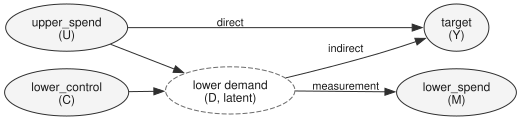

In [1]:
import graphviz as gr

# DAG styling: observed (filled) vs latent (dashed outline) only.
# Entity colors for time-series plots are defined in the setup cell below.
DAG_OBSERVED_FILL = "#f4f4f4"
DAG_OBSERVED_STROKE = "#2f2f2f"
DAG_LATENT_STROKE = "#6b6b6b"
DAG_FONT = "#1a1a1a"
DAG_EDGE = "#2f2f2f"

_observed = {
    "style": "filled",
    "fillcolor": DAG_OBSERVED_FILL,
    "color": DAG_OBSERVED_STROKE,
    "fontcolor": DAG_FONT,
}
_latent = {
    "style": "dashed",
    "color": DAG_LATENT_STROKE,
    "fontcolor": DAG_FONT,
}

g = gr.Digraph()
g.attr(rankdir="LR", bgcolor="transparent")
g.attr("node", fontname="Helvetica", fontsize="12")
g.attr("edge", color=DAG_EDGE, fontcolor=DAG_FONT, fontname="Helvetica", fontsize="11")

g.node("U", "upper_spend\n(U)", **_observed)
g.node("C", "lower_control\n(C)", **_observed)
g.node("D", "lower demand\n(D, latent)", **_latent)
g.node("M", "lower_spend\n(M)", **_observed)
g.node("Y", "target\n(Y)", **_observed)

g.edge("U", "Y", label="direct")
g.edge("U", "D")
g.edge("C", "D")
g.edge("D", "M", label="measurement")
g.edge("D", "Y", label="indirect")

g

**Caption:** Causal DAG for the minimal funnel. Filled nodes are observed in the data ($U$, $C$, $M$, $Y$); the dashed node $D$ is latent lower-funnel demand. Solid arrows are structural; the $D \to M$ edge is a measurement link.


Each node in the DAG maps to a variable in the data generating process:

- `upper_spend` ($U_t$): an exogenous upper-funnel channel.
- `lower_control` ($C_t$): an exogenous driver of lower-funnel demand that is *independent* of `upper_spend` (think auction / category-demand pressure). It enters the **mediator** equation but is **excluded from the outcome equation**. That absence from $Y$'s parents, together with exogeneity of $C$, supports separating the **direct** path from the **indirect** path mediated by lower-funnel demand.
- `lower_spend` ($M_t$): the **observed** lower-funnel channel. It is an **outcome** of latent demand (driven partly by upper-funnel activity) and a **proxy** for that demand in the data; the target responds to $D_t$, not to $M_t$ directly.
- `y` ($Y_t$): the target (e.g. leads or sales).

Structural equations use $=$; observed variables use $\sim$.

The data generating process has three pieces:

$$
\begin{aligned}
D_t &= \beta_0 + \gamma\, C_t + f_{u\to l}(U_t), \\
M_t &\sim \text{TruncatedNormal}(D_t,\, \sigma_M,\, \text{lower}=0), \\
\mu_t &= \alpha + f_{\text{direct}}(U_t) + f_{l\to y}(D_t), \\
Y_t &\sim \text{Normal}(\mu_t,\, \sigma_Y).
\end{aligned}
$$

First, $f_{u\to l} = \text{saturation}_{uf}(\text{adstock}_{uf}(U))$ transforms upper spend into induced lower-funnel demand. Second, observed lower-funnel spend is a noisy proxy for that demand (the model's *second likelihood*). Third, the target responds to latent demand $D_t$, not observed spend $M_t$, with $f_{\text{direct}} = \text{saturation}(\text{adstock}(U))$ the **direct** effect of upper spend and $f_{l\to y} = \text{saturation}_{lf}(\text{adstock}_{lf}(D))$ the lower-funnel response.

Because $Y$ enters through $D_t$, shocks that move $M_t$ without moving $D_t$ (auction noise, pacing, bid shocks) do not affect $Y_t$. Only the systematic demand $D_t$ mediates the indirect path. That is what makes the mediation *structural*: an intervention on $U$ propagates through $D_t$ into both the observed spend and the target.

Reading the DAG above, there are **two paths** from `upper_spend` to the target:

- the **direct** path $U \to Y$, and
- the **indirect** path $U \to D \to Y$, mediated by latent lower-funnel demand $D$ (with exogenous control $C \to D$ and measurement $D \to M$ for observed `lower_spend`).

Note the **four independently estimated media transforms**: upper-funnel spend has its own adstock and saturation on the way to lower-funnel demand, and lower-funnel demand has its own adstock and saturation on the way to the target, in addition to the direct upper $\to$ target transform.

### Measurement, not a budget lever

In this DAG, observed `lower_spend` enters only through the measurement edge $D \to M$. Nothing points **out of** $M$ into $Y$; the target responds to latent demand $D$, not to noisy execution in spend. An intervention `do(lower_spend)` has **zero** effect on $Y$ by construction. This notebook answers how much credit upper-funnel spend deserves (direct, indirect, total), not whether to reallocate budget to lower-funnel media. That allocation question requires a graph where lower-funnel spend is a **cause** of the target, not merely a proxy for demand.

```{note}
**Deliberate extreme case.** In most real funnels, lower-funnel spend also has a direct incremental effect on the target (an $M \to Y$ edge), often smaller than upper-funnel's total impact but not zero. This notebook **omits** that edge on purpose: it isolates upper $\to$ lower **mediation** and the bias from treating the mediator as an ordinary channel (Naive A). A production model aimed at **budget split** between upper and lower would typically add $M \to Y$ (or a structural lower-media variable with its own exogenous budget), at the cost of a harder identification problem. Read "no $M \to Y$" as a teaching simplification, not a claim that paid search never drives sales.
```


## Prepare Notebook


In [2]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from pydantic import InstanceOf
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.metrics import crps
from pymc_marketing.mmm import (
    AdstockTransformation,
    GeometricAdstock,
    LogisticSaturation,
    SaturationTransformation,
)
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.mmm import MMM

FIG_WIDTH = 10
FIG_HEIGHT = 6
COLOR_DIRECT = "C0"
COLOR_INDIRECT = "C1"
COLOR_TRUE = "black"

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = sum(map(ord, "funnel"))
rng: np.random.Generator = np.random.default_rng(seed=seed)


def hdi_bounds(da, prob: float = 0.94):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")


def compute_target_metrics(
    model, y_true: np.ndarray, dates: pd.DatetimeIndex | None = None
):
    """Return RMSE, R², and CRPS on the original target scale for posterior-predictive y."""
    target_scale = float(model.idata.constant_data["target_scale"].squeeze())
    pp = model.idata.posterior_predictive["y"]
    if dates is not None:
        pp = pp.sel(date=dates.to_numpy())
    yhat = pp.mean(dim=[d for d in pp.dims if d != "date"]).to_numpy().ravel()
    yhat = yhat * target_scale
    y_true = np.asarray(y_true).ravel()
    if len(yhat) != len(y_true):
        raise ValueError(
            f"Length mismatch: {len(yhat)} posterior-predictive dates vs {len(y_true)} y values."
        )
    ss_res = ((y_true - yhat) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    rmse = float(np.sqrt(ss_res / len(y_true)))
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    y_pred = (
        pp.stack(sample=("chain", "draw")).transpose("sample", "date").to_numpy()
        * target_scale
    )
    crps_val = float(crps(y_true, y_pred))
    return rmse, r2, crps_val

## The `FunnelEffect` component

`pymc-marketing`'s `MMM` builds the target mean as $\mu = \text{baseline} + \sum \text{contributions}$ with a single likelihood. A {class}`~pymc_marketing.mmm.additive_effect.MuEffect` is the sanctioned way to add an arbitrary term to that mean. It follows a three-method protocol:

- `create_data(mmm)`: register any `pymc.dims.Data` the effect needs.
- `create_effect(mmm)`: return a tensor with dims `("date", *mmm.dims)` that is **added** to the target mean.
- `set_data(mmm, model, X)`: refresh the data at prediction time.

We subclass {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect`, which implements `create_data` and `set_data` for us: each variable listed in `data_vars` is read from the `xr.Dataset` passed as `X` at fit time and refreshed from the new `X` at prediction time. That means the effect supports **out-of-sample prediction**: pass future `lower_control` values (the control is exogenous, so it must be supplied like any other regressor) and placeholder `lower_spend` values; the second likelihood is resampled, so the model *forecasts* lower-funnel spend rather than consuming it. Only `create_effect` is left for us to implement.

```{note}
`make_mmm_dataset` below is notebook-local: the DataFrame API carries only channel and control columns, so mediator series (`lower_spend`, `lower_control`) must travel in an `xr.Dataset`. There is no library helper for this yet.
```

The key move for funnel modeling is that `create_effect` runs *inside* the model context, so nothing stops it from declaring **its own observed likelihood**. That turns "add a term to `mu`" into "fit a second structural equation jointly with the target". Our `FunnelEffect` does exactly that:

1. It reads the (scaled) upper-funnel spend already registered by the base `MMM`.
2. It builds the latent lower-funnel **demand** from upper spend (with its own adstock + saturation) plus a baseline and the exogenous control.
3. It attaches a **second likelihood** for the observed lower-funnel spend to that demand.
4. It returns the lower-funnel $\to$ target contribution (with a *second* adstock + saturation) to be added to the target mean.
One more method is worth implementing here, though it is optional in general. Because this effect reads upper-funnel spend, a spend counterfactual reaches the target *through it* as well as through `channel_contribution`. When `incrementality_spec` returns an {class}`~pymc_marketing.mmm.additive_effect.IncrementalitySpec`, the incrementality module includes the mediated path in its ROAS numbers rather than reporting the direct path alone. The empty spec is enough: how far the mediator carries a change in spend is measured from the fitted graph rather than declared.

```{warning}
**Notebook-local implementation.** Treatment is wired via `mmm.channel_data_scaled.isel(channel=0)`: a positional index that silently targets the wrong channel if `channel_columns` is reordered. `DataVarMuEffect` registers `pmd.Data` under unprefixed variable names, so two effects sharing a control name (e.g. `lower_control`) would collide at build time. See [pymc-marketing#2871](https://github.com/pymc-labs/pymc-marketing/issues/2871) for follow-up if promoting this pattern to the library.
```


In [4]:
class FunnelEffect(DataVarMuEffect):
    """Upper- to lower-funnel mediation with its own likelihood.

    Encodes the indirect path ``upper_spend -> lower_demand -> target`` as an
    additive effect on the target mean, while jointly fitting the lower-funnel
    spend through a second (truncated normal) likelihood.

    ``DataVarMuEffect`` supplies ``create_data`` and ``set_data``: the series
    named in ``data_vars`` are read from the ``xr.Dataset`` passed as ``X`` at
    fit time and refreshed from the new ``X`` at prediction time, so the effect
    works out of sample.
    """

    data_vars: list[str] = ["lower_spend", "lower_control"]
    prefix: str = "funnel"
    adstock_uf: InstanceOf[AdstockTransformation]
    saturation_uf: InstanceOf[SaturationTransformation]
    adstock_lf: InstanceOf[AdstockTransformation]
    saturation_lf: InstanceOf[SaturationTransformation]

    def to_dict(self) -> dict:
        """Serialize the effect (media transforms delegate to their own dicts)."""
        return {
            "prefix": self.prefix,
            "data_vars": list(self.data_vars),
            "adstock_uf": self.adstock_uf.to_dict(),
            "saturation_uf": self.saturation_uf.to_dict(),
            "adstock_lf": self.adstock_lf.to_dict(),
            "saturation_lf": self.saturation_lf.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Let a spend counterfactual travel through the mediated path.

        This effect reads ``mmm.channel_data_scaled``, so perturbing upper-funnel
        spend moves its contribution as well as ``channel_contribution``. Opting
        in tells {class}`~pymc_marketing.mmm.incrementality.Incrementality` to
        include that movement in the increment. Nothing has to be declared: the
        extra reach of the second adstock is measured off the fitted graph.
        """
        return IncrementalitySpec()

    def create_effect(self, mmm):
        """Build the mediator equation (+ its likelihood) and return the effect."""
        model = mmm.model
        # Reuse the scaled upper-funnel spend already built by the base MMM.
        upper = mmm.channel_data_scaled.isel(channel=0)

        # Structural equation 1: upper spend -> latent lower-funnel demand.
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0)
        upper_on_lower = self.saturation_uf.apply(
            self.adstock_uf.apply(upper, core_dim="date"), core_dim="date"
        )
        demand = pmd.Deterministic(
            f"{self.prefix}_lower_demand",
            baseline + gamma * model["lower_control"] + upper_on_lower,
        )

        # Second likelihood: observed lower-funnel spend around latent demand.
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_likelihood",
            mu=demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma", sigma=1.0),
            lower=0.0,
            observed=model["lower_spend"],
        )

        # Structural equation 2: latent demand -> target contribution.
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.saturation_lf.apply(
                self.adstock_lf.apply(demand, core_dim="date"), core_dim="date"
            ),
        )

## Data generating process

We follow the same recipe as the {ref}`mmm_data_generator` notebook: build a PyMC model, clamp the parameters to known ground-truth values with the [`do`](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model.transform.conditioning.do.html) operator, and forward-sample. The twist here is that the generative model **is** the funnel MMM (base `MMM` + `FunnelEffect`), so a single forward pass produces **both** the observed lower-funnel spend and the target.


### Configuration


In [5]:
n_dates = 130
l_max = 8

date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)
coords = {"date": date_range}

### Exogenous covariates

We draw `upper_spend` and `lower_control` from a small PyMC model with an LKJ prior on the (near-diagonal) correlation structure and a `softplus` transform to keep spend non-negative. We deliberately make the two drivers close to independent: the control is an *exogenous* source of lower-funnel variation, which is what identifies the mediator equation separately from the direct path.


In [6]:
t = np.arange(n_dates) / n_dates
cov_coords = {"date": date_range, "driver": ["upper_spend", "lower_control"]}

with pm.Model(coords=cov_coords) as covariates_model:
    t_data = pm.Data("t", t, dims=("date",))
    L, _, _ = pm.LKJCholeskyCov("L", n=2, eta=100, sd_dist=pm.Exponential.dist(lam=1.0))
    a = pm.Normal("a", mu=0, sigma=1, dims="driver")
    b = pm.Normal("b", mu=0, sigma=1, dims="driver")
    mu_cov = pm.Deterministic(
        "mu_cov", a + b * t_data[..., None], dims=("date", "driver")
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "driver"))

In [7]:
x_data = pm.draw(covariates_model.x, draws=1, random_seed=rng)

df = pd.DataFrame(
    {
        "date": date_range,
        "upper_spend": x_data[:, 0],
        "lower_control": x_data[:, 1],
        # Placeholder: the generative model draws the actual lower spend below.
        "lower_spend": np.ones(n_dates),
        "y_dummy": np.ones(n_dates),
    }
)
df.head()

,date,upper_spend,lower_control,lower_spend,y_dummy
0,2021-01-04,0.204664,0.936577,1.0,1.0
1,2021-01-11,1.966219,1.587323,1.0,1.0
2,2021-01-18,1.196404,1.353986,1.0,1.0
3,2021-01-25,0.067877,0.572868,1.0,1.0
4,2021-02-01,0.560784,0.703662,1.0,1.0


### Ground-truth parameters

We fix explicit true values for every structural parameter. Splitting the effect of upper spend across a direct and an indirect path is the whole point, so we pick values where **both paths carry meaningful weight**.


In [8]:
true = {
    "intercept_contribution": 0.25,
    # direct path: upper -> target
    "adstock_alpha": 0.45,
    "saturation_lam": 4.0,
    "saturation_beta": 0.80,
    "y_sigma": 0.05,
    # mediator equation: upper -> lower-funnel demand
    "funnel_baseline": 0.15,
    "funnel_gamma": 0.25,
    "adstock_uf_alpha": 0.50,
    "sat_uf_lam": 2.5,
    "sat_uf_beta": 1.3,
    "funnel_sigma": 0.04,
    # lower-funnel path: lower demand -> target
    "adstock_lf_alpha": 0.30,
    "sat_lf_lam": 1.2,
    "sat_lf_beta": 1.1,
}
true = {k: np.asarray(v, dtype=float) for k, v in true.items()}

In [9]:
def make_funnel_effect():
    """Construct a FunnelEffect with fresh, uniquely-prefixed media transforms."""
    return FunnelEffect(
        adstock_uf=GeometricAdstock(l_max=l_max, prefix="adstock_uf"),
        saturation_uf=LogisticSaturation(prefix="sat_uf"),
        adstock_lf=GeometricAdstock(l_max=l_max, prefix="adstock_lf"),
        saturation_lf=LogisticSaturation(prefix="sat_lf"),
    )


def make_mmm_dataset(frame):
    """Bundle the MMM inputs into an ``xr.Dataset``.

    The DataFrame API only keeps channel / control columns, so the extra
    mediator series ride along as data variables of an ``xr.Dataset``: the
    format ``DataVarMuEffect`` reads from at both fit and prediction time.
    """
    dates = pd.to_datetime(frame["date"]).to_numpy()
    return xr.Dataset(
        {
            "media": xr.DataArray(
                frame[["upper_spend"]].to_numpy(dtype=float),
                dims=("date", "channel"),
                coords={"date": dates, "channel": ["upper_spend"]},
            ),
            "lower_spend": xr.DataArray(
                frame["lower_spend"].to_numpy(dtype=float),
                dims=("date",),
                coords={"date": dates},
            ),
            "lower_control": xr.DataArray(
                frame["lower_control"].to_numpy(dtype=float),
                dims=("date",),
                coords={"date": dates},
            ),
        }
    )

### Forward simulation

We build the funnel MMM on the dummy target, register original-scale contribution variables (so we can read off the true decomposition), clamp the parameters to their true values, and forward-sample. The base `MMM` supplies the intercept and the **direct** upper $\to$ target contribution; the `FunnelEffect` supplies the mediator likelihood and the **indirect** contribution.


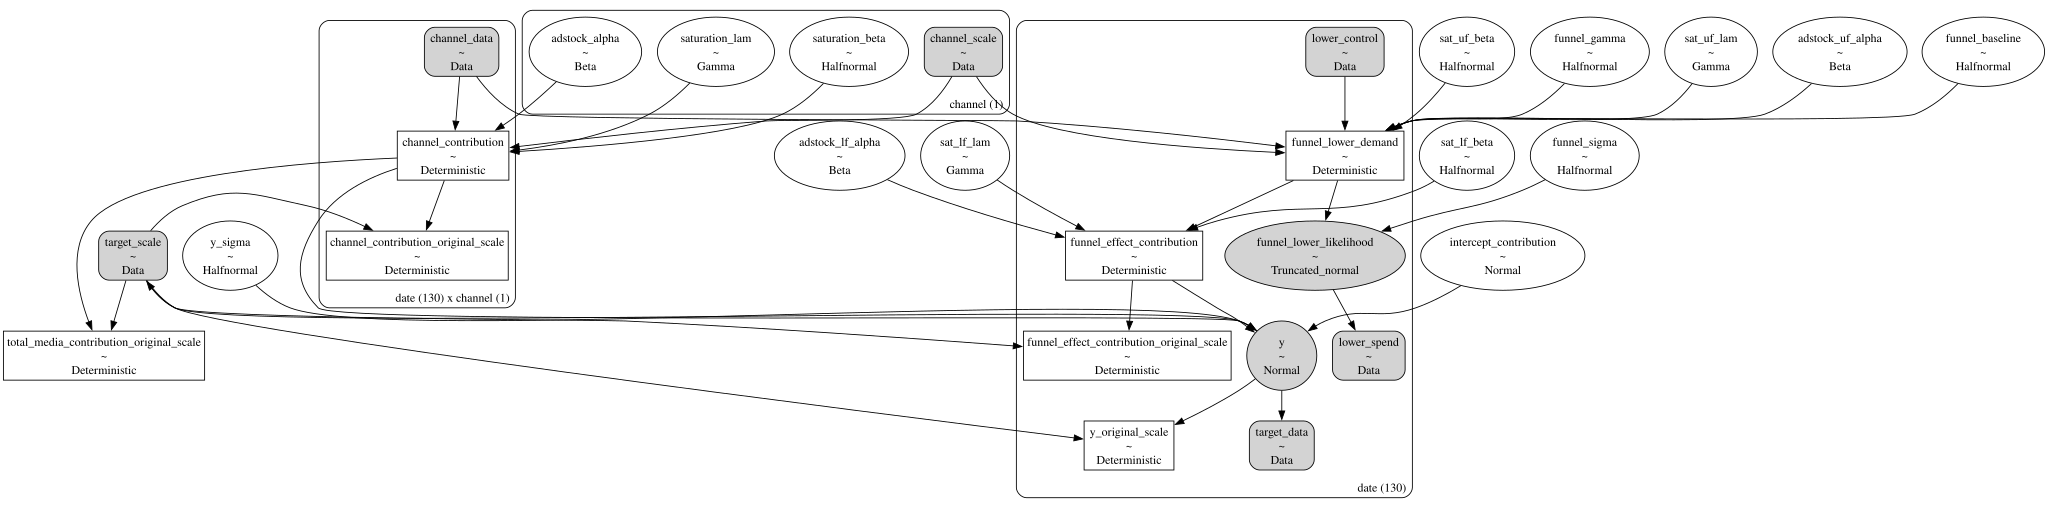

In [10]:
model_config_gen = {
    "intercept": Prior("Normal", mu=0.3, sigma=0.1),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.1)),
}

gen = MMM(
    date_column="date",
    target_column="y_dummy",
    channel_columns=["upper_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    model_config=model_config_gen,
)
gen.add_mu_effect(make_funnel_effect())

X_gen = make_mmm_dataset(df)
gen.build_model(X_gen, df["y_dummy"])
gen.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)

pm.model_to_graphviz(gen.model)

The graph above makes the two likelihoods explicit: `funnel_lower_likelihood` (observed lower-funnel spend) and `y` (the target) are both children of the same set of latent parameters. Now we clamp the parameters and forward-sample. Note that the two channel-dimensioned direct-path parameters need a length-1 array.


In [11]:
channel_dim_vars = {"adstock_alpha", "saturation_lam", "saturation_beta"}
intervention = {
    k: (true[k].reshape(1) if k in channel_dim_vars else true[k]) for k in true
}
gen.model = do(gen.model, intervention)

In [12]:
with gen.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1,
        var_names=[
            "y_original_scale",
            "channel_contribution_original_scale",
            "funnel_effect_contribution_original_scale",
            "funnel_lower_likelihood",
        ],
        random_seed=rng,
    )

prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior["y_original_scale"].to_numpy().ravel()
lower_spend_obs = prior_pp["funnel_lower_likelihood"].to_numpy().ravel()
direct_true = (
    prior["channel_contribution_original_scale"].isel(channel=0).to_numpy().ravel()
)
indirect_raw = prior["funnel_effect_contribution_original_scale"].to_numpy().ravel()

/Users/benjamv/git/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_likelihood, y]


The raw `funnel_effect_contribution` includes the part of lower-funnel demand that comes from the baseline and the control, not from upper spend. To isolate the **causal** contribution of upper spend through the mediator, we re-run the clamped generative model with `upper_spend` set to zero and subtract.


In [13]:
with gen.model:
    pm.set_data({"channel_data": np.zeros((n_dates, 1))})
    idata_cf = pm.sample_prior_predictive(
        draws=1,
        var_names=["y_original_scale", "funnel_effect_contribution_original_scale"],
        random_seed=rng,
    )

prior_cf = idata_cf["prior"].sel(chain=0, draw=0)
indirect_upper0 = (
    prior_cf["funnel_effect_contribution_original_scale"].to_numpy().ravel()
)

# Restore the generative model's upper-funnel spend.
with gen.model:
    pm.set_data({"channel_data": df[["upper_spend"]].to_numpy()})

indirect_true = indirect_raw - indirect_upper0  # causal indirect contribution
total_upper_true = direct_true + indirect_true

Sampling: [y]


In [14]:
df["y_obs"] = y_obs
df["lower_spend"] = lower_spend_obs
df["direct_true"] = direct_true
df["indirect_true"] = indirect_true
df["total_upper_true"] = total_upper_true

# Drop the first ``l_max`` rows: the adstock transform needs a burn-in window.
df = df.tail(-l_max).reset_index(drop=True)

share = df["indirect_true"].mean() / df["total_upper_true"].mean()
print(f"Mean direct contribution:   {df['direct_true'].mean():.3f}")
print(f"Mean indirect contribution: {df['indirect_true'].mean():.3f}")
print(f"Indirect share of upper-funnel effect: {share:.1%}")
df.head()

Mean direct contribution:   0.335
Mean indirect contribution: 0.199
Indirect share of upper-funnel effect: 37.2%


,date,upper_spend,lower_control,lower_spend,y_dummy,y_obs,direct_true,indirect_true,total_upper_true
0,2021-03-01,0.018898,1.202925,0.497827,1.0,0.581179,0.063864,0.051634,0.115498
1,2021-03-08,1.458776,1.691106,0.807176,1.0,0.863601,0.222916,0.102511,0.325427
2,2021-03-15,2.441249,0.987102,0.762176,1.0,1.143889,0.399293,0.195352,0.594646
3,2021-03-22,0.004147,0.690200,0.430669,1.0,0.859813,0.193942,0.150145,0.344087
4,2021-03-29,0.120347,1.127780,0.540130,1.0,0.669259,0.104861,0.095827,0.200688


**Caption:** Weekly time series of the synthetic target, upper-funnel spend, observed lower-funnel spend (mediator), and exogenous lower-funnel control.


### Exploratory visualization


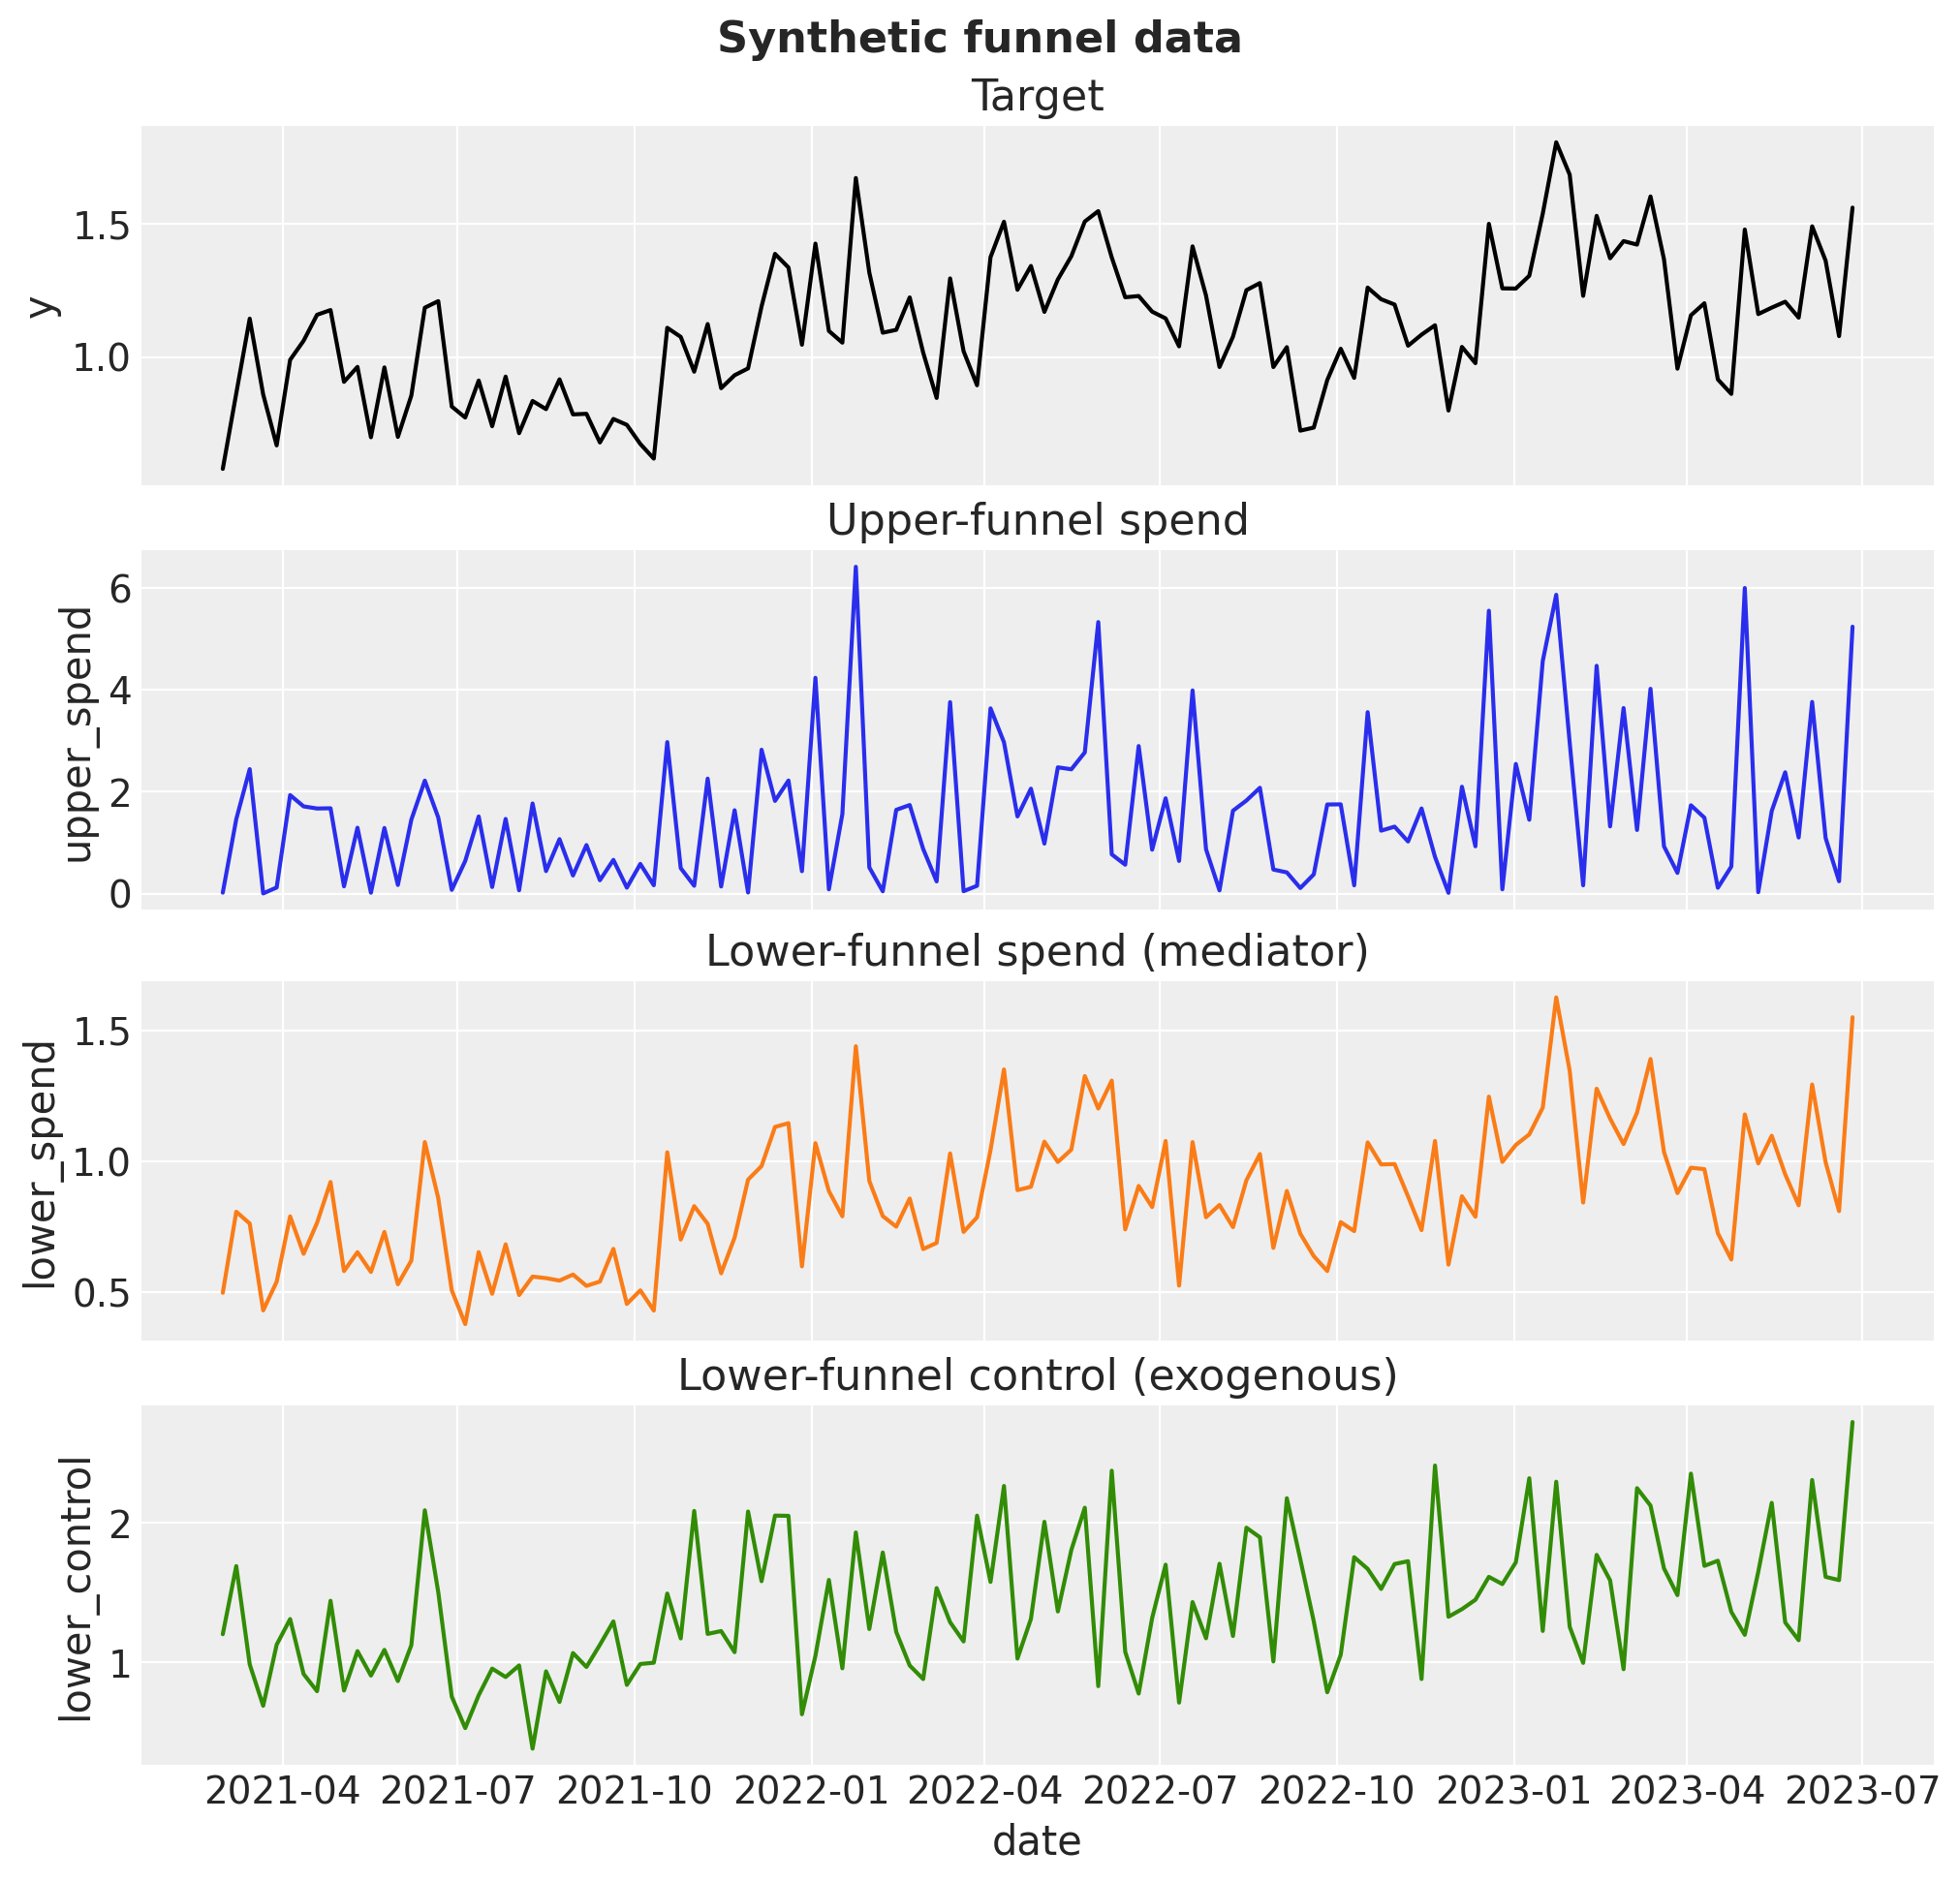

In [15]:
fig, ax = plt.subplots(nrows=4, figsize=(FIG_WIDTH, FIG_HEIGHT * 1.6), sharex=True)

sns.lineplot(x="date", y="y_obs", data=df, color="black", ax=ax[0])
ax[0].set(title="Target", ylabel="y")
sns.lineplot(x="date", y="upper_spend", data=df, color="C0", ax=ax[1])
ax[1].set(title="Upper-funnel spend", ylabel="upper_spend")
sns.lineplot(x="date", y="lower_spend", data=df, color="C1", ax=ax[2])
ax[2].set(title="Lower-funnel spend (mediator)", ylabel="lower_spend")
sns.lineplot(x="date", y="lower_control", data=df, color="C2", ax=ax[3])
ax[3].set(title="Lower-funnel control (exogenous)", ylabel="lower_control")
fig.suptitle("Synthetic funnel data", fontsize=16, fontweight="bold");

The true decomposition of upper-funnel spend into its direct and indirect (mediated) contributions. This is the ground truth the models will try to recover.


**Caption:** Ground-truth decomposition of upper-funnel spend into direct ($U \to Y$), indirect ($U \to D \to Y$), and total paths (weekly, original target scale).


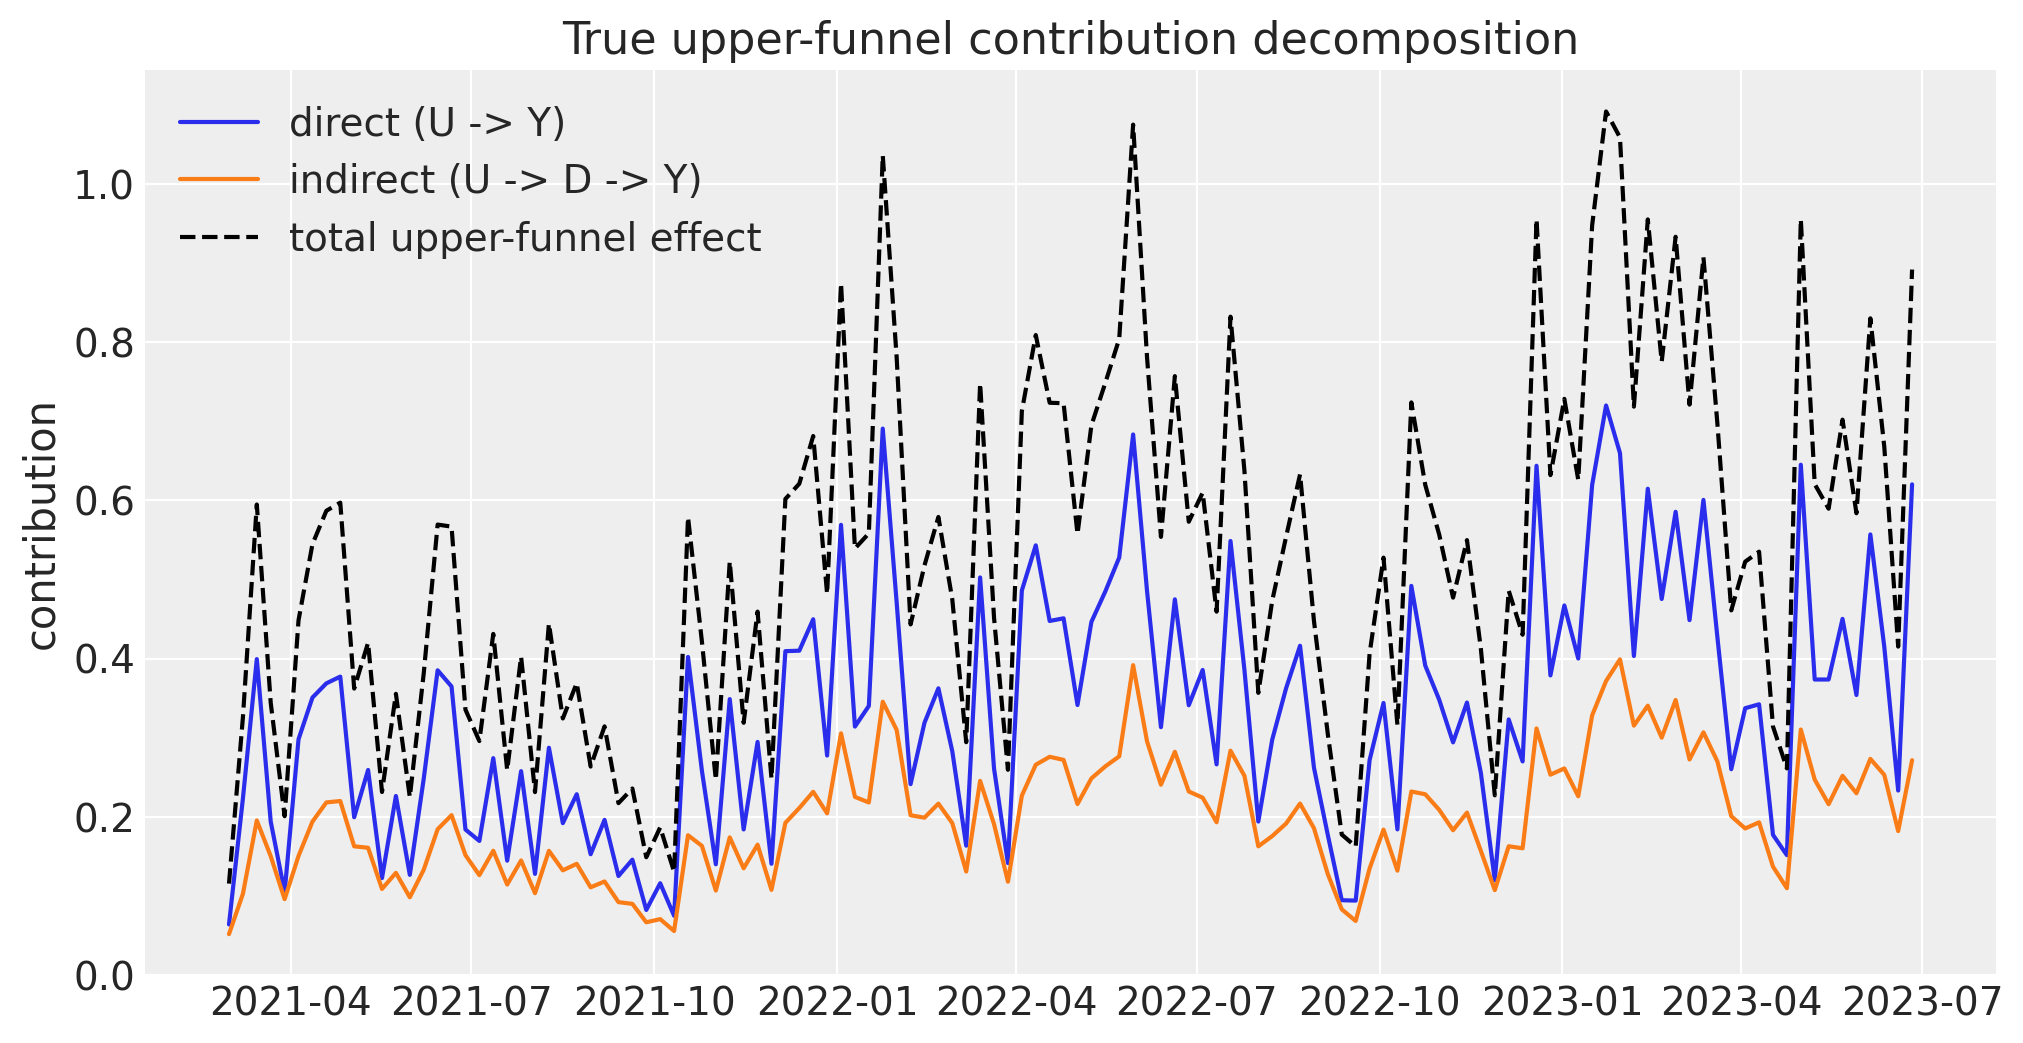

In [16]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.85))
ax.plot(df["date"], df["direct_true"], label="direct (U -> Y)", color=COLOR_DIRECT)
ax.plot(
    df["date"],
    df["indirect_true"],
    label="indirect (U -> D -> Y)",
    color=COLOR_INDIRECT,
)
ax.plot(
    df["date"],
    df["total_upper_true"],
    label="total upper-funnel effect",
    color=COLOR_TRUE,
    linestyle="--",
)
ax.legend(loc="upper left")
ax.set(title="True upper-funnel contribution decomposition", ylabel="contribution");

## Fitting the models

We now fit three models on the synthetic data:

- **Naive A**: a standard MMM with the mediator included as an **ordinary channel** (`upper_spend` and `lower_spend` side by side).
- **Naive B**: a standard MMM with the mediator **omitted** (`upper_spend` only).
- **Funnel**: the joint model with the `FunnelEffect`.

All three use the same adstock/saturation families and the same sampler settings.


In [17]:
# The naive models use the DataFrame API; the funnel model takes the xr.Dataset
# so the mediator series travel with X (see ``make_mmm_dataset``).
X = df[["date", "upper_spend", "lower_spend"]]
X_funnel = make_mmm_dataset(df)
y = df["y_obs"]

sample_kwargs = dict(
    chains=4, tune=1_000, draws=1_000, target_accept=0.9, random_seed=rng
)
sampler_config = {"nuts_sampler": "nutpie"}

### Naive A: mediator as an ordinary channel

This is what most production MMMs do when they have both upper- and lower-funnel spend: drop them side by side as independent channels. Conditioning on the mediator **blocks the indirect path**, so `upper_spend` is credited with (at most) its direct effect, and the lower-funnel channel is over-credited with demand that upper-funnel activity created.

```{important}
Treating funnel layers as independent channels is a **common error**, not an exotic edge case; it is the default configuration of most production MMMs. Modeling the funnel explicitly is not just more descriptive: as the head-to-head comparison below shows, it is the only one of the three models that recovers **unbiased** upper-funnel estimates.
```


In [18]:
naive_a = MMM(
    date_column="date",
    target_column="y_obs",
    channel_columns=["upper_spend", "lower_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    sampler_config=sampler_config,
)
naive_a.build_model(X, y)
naive_a.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_a.fit(X, y, **sample_kwargs)
naive_a.sample_posterior_predictive(X, random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive B: mediator omitted

Here `upper_spend` is the only channel. Its response curve is forced to absorb *both* the direct effect and the demand it creates downstream, with no separate lower-funnel lever. Because the mediator is gone, that single curve also has to soak up the exogenous, control-driven fluctuations in lower-funnel demand that move the target but are unrelated to upper spend, with nowhere else to attribute them. Fitting one saturation curve to this composite relationship generally biases the upper-funnel estimate; here, upward.


In [19]:
naive_b = MMM(
    date_column="date",
    target_column="y_obs",
    channel_columns=["upper_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    sampler_config=sampler_config,
)
naive_b.build_model(X[["date", "upper_spend"]], y)
naive_b.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_b.fit(X[["date", "upper_spend"]], y, **sample_kwargs)
naive_b.sample_posterior_predictive(X[["date", "upper_spend"]], random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### The funnel model

The funnel model has `upper_spend` as its only channel (its direct effect) plus the `FunnelEffect`, which reads the **real** generated lower-funnel spend and control from the `X` dataset. It fits the lower-funnel spend and the target jointly.


In [20]:
funnel = MMM(
    date_column="date",
    target_column="y_obs",
    channel_columns=["upper_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    sampler_config=sampler_config,
)
funnel.add_mu_effect(make_funnel_effect())
funnel.build_model(X_funnel, y)
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)
funnel.fit(X_funnel, y, **sample_kwargs)
funnel.sample_posterior_predictive(X_funnel, random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma]


Output()

Output()

/Users/benjamv/git/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_likelihood, y]


Output()

### Diagnostics


In [21]:
for label, m in [("Naive A", naive_a), ("Naive B", naive_b), ("Funnel", funnel)]:
    divergences = int(m.idata["sample_stats"]["diverging"].sum())
    max_rhat = float(az.summary(m.idata)["r_hat"].max())
    print(f"{label:8s} | divergences: {divergences:3d} | max r-hat: {max_rhat:.3f}")

Naive A  | divergences:   0 | max r-hat: 1.020


Naive B  | divergences:   0 | max r-hat: 1.000


Funnel   | divergences:   0 | max r-hat: 1.010


### Posterior predictive checks

The funnel model has **two** observed quantities. Both should be well recovered: the target and the lower-funnel spend.


**Caption:** Funnel model posterior predictive check for the target $Y$: posterior mean and 94% HDI bands vs. observed `y_obs` (original scale).


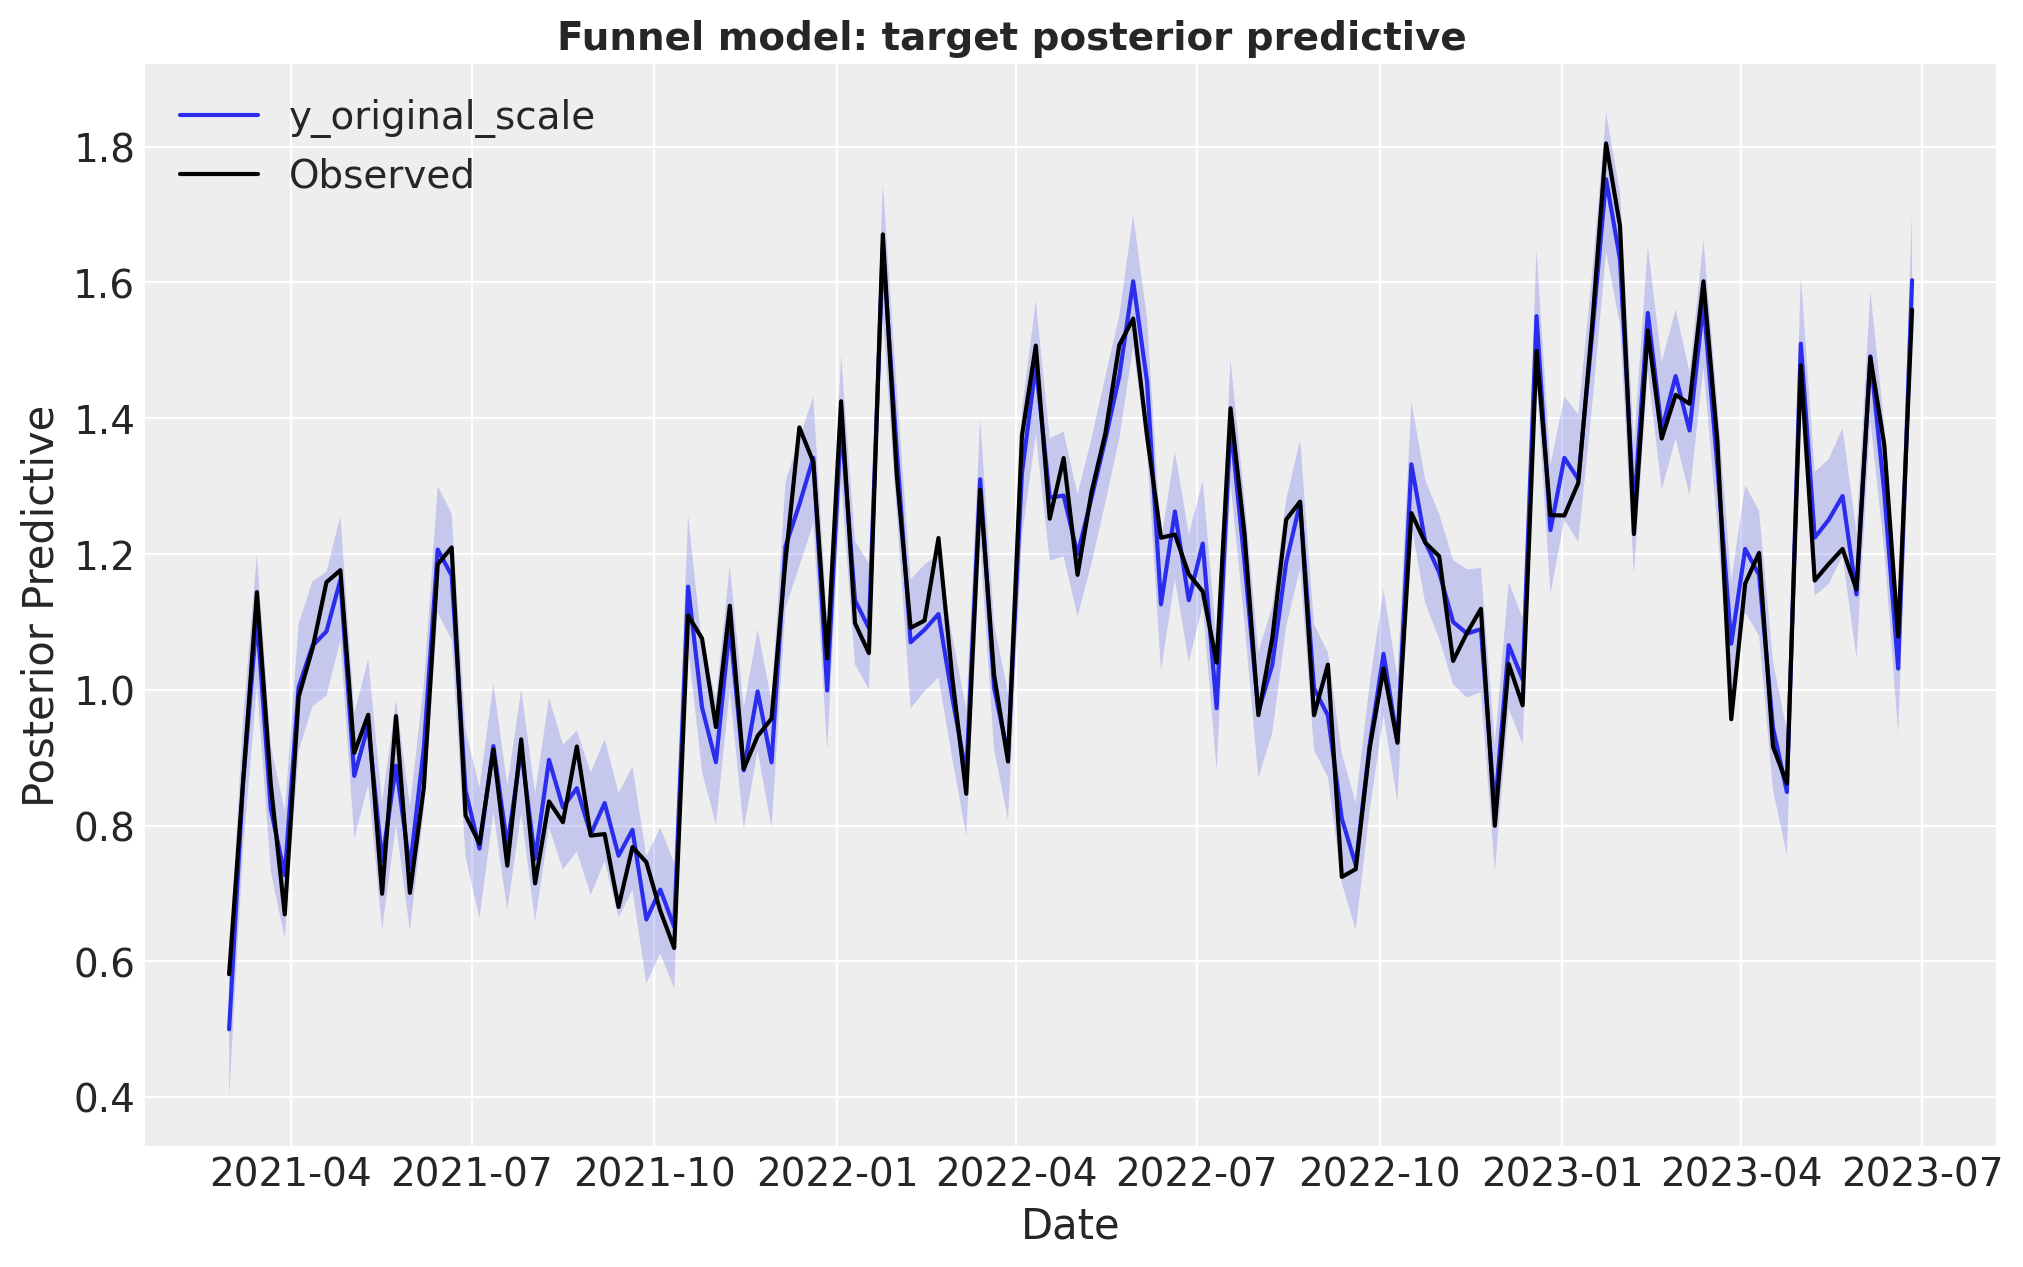

In [22]:
funnel.plot_suite = "new"
fig, axes = funnel.plot.diagnostics.posterior_predictive(hdi_prob=0.94)
axes.flatten()[0].legend()
fig.suptitle(
    "Funnel model: target posterior predictive", fontsize=14, fontweight="bold", y=1.03
);

**Caption:** Funnel model posterior predictive for observed lower-funnel spend $M$: posterior mean and 94% HDI vs. observed `lower_spend` (second likelihood).


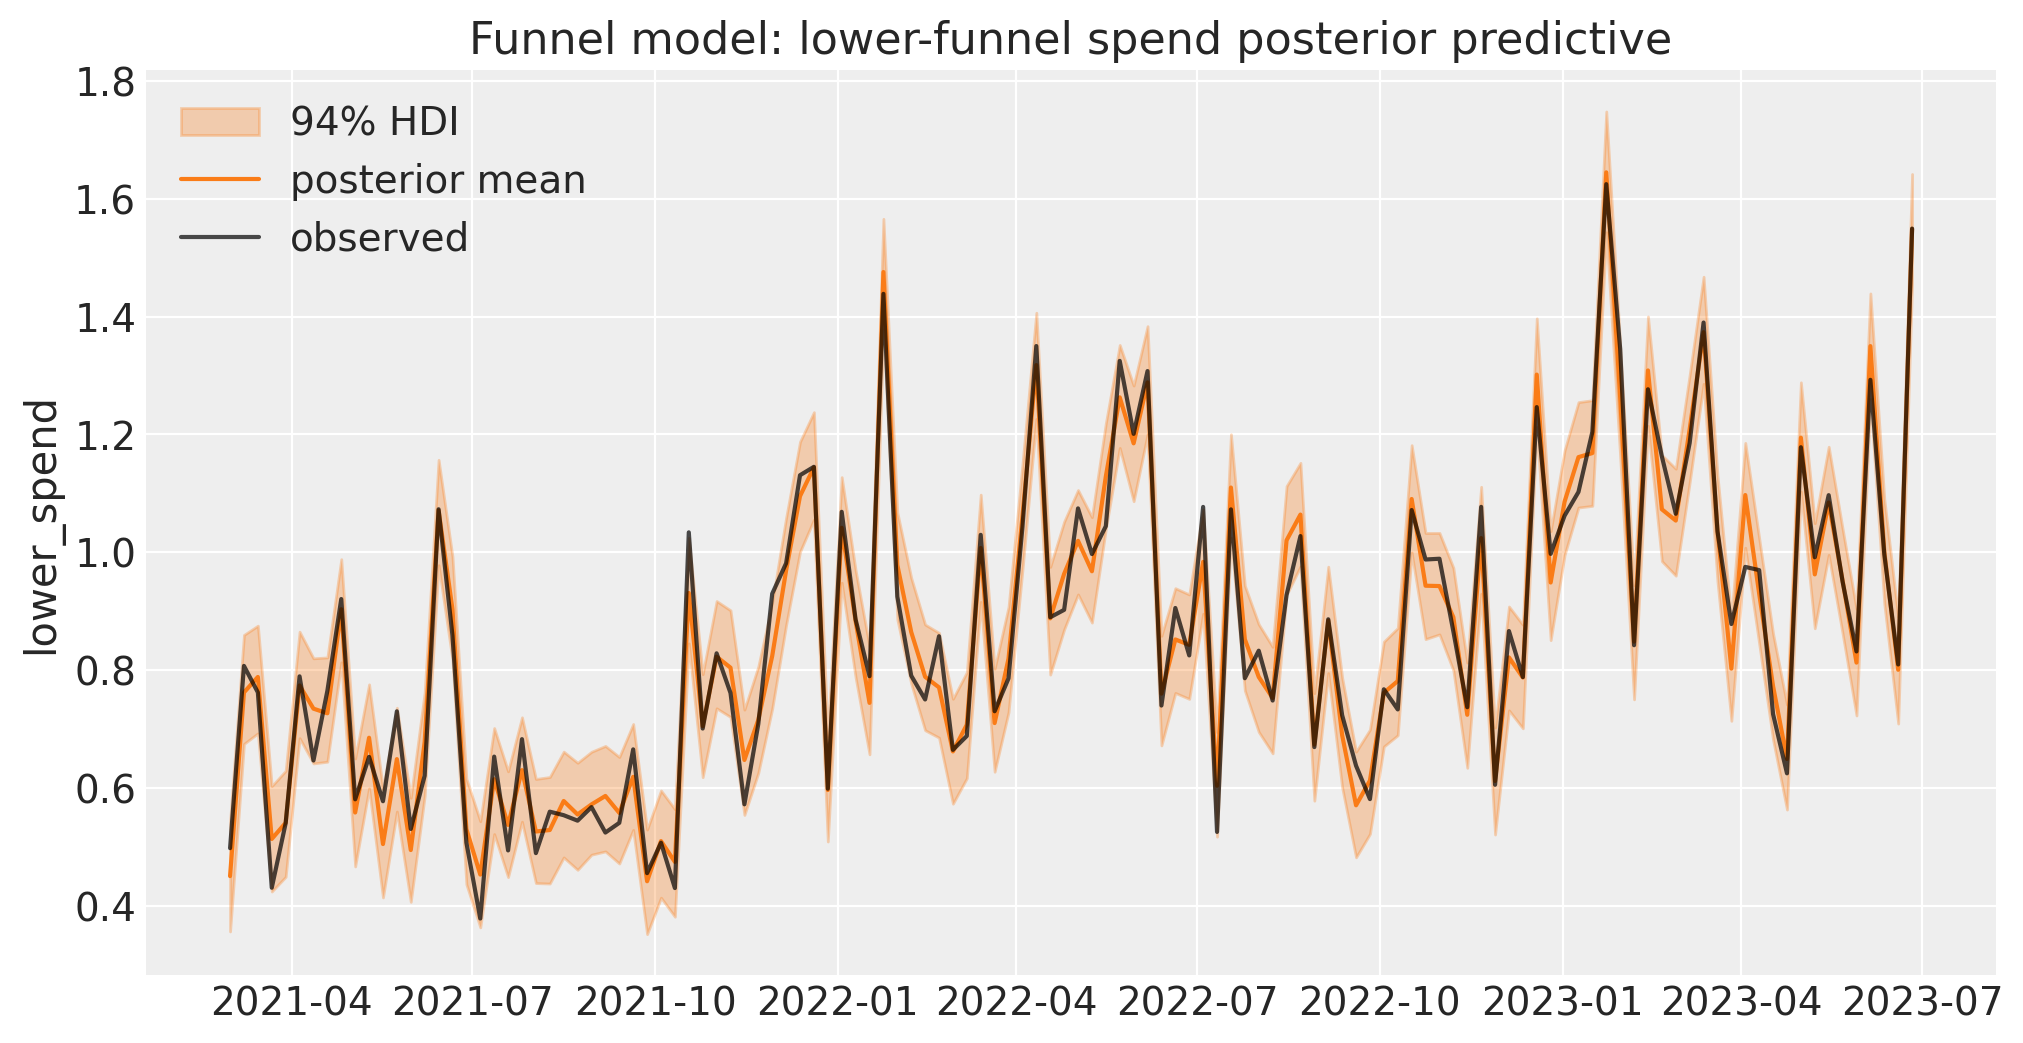

In [23]:
lower_pp = funnel.idata.posterior_predictive["funnel_lower_likelihood"]
lower_mean = lower_pp.mean(dim=[d for d in lower_pp.dims if d != "date"]).to_numpy()
lower_lo, lower_hi = hdi_bounds(lower_pp)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.85))
ax.fill_between(
    df["date"],
    lower_lo,
    lower_hi,
    alpha=0.3,
    color="C1",
    label="94% HDI",
)
ax.plot(df["date"], lower_mean, color="C1", label="posterior mean")
ax.plot(df["date"], df["lower_spend"], color="black", label="observed", alpha=0.7)
ax.legend(loc="upper left")
ax.set(
    title="Funnel model: lower-funnel spend posterior predictive", ylabel="lower_spend"
);

## Parameter recovery

Because we generated the data, we can check whether the funnel model recovers the true parameters. We overlay the true value (dashed line) on each posterior.


**Caption:** Posterior marginals for nine funnel-model parameters vs. planted ground truth (dashed black). Amplitude parameters on the scaled target are rescaled by `target_scale` before comparison.


/var/folders/r0/nf1kgxsx6zx3rw16xc3wnnzr0000gn/T/ipykernel_2999/4242178776.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


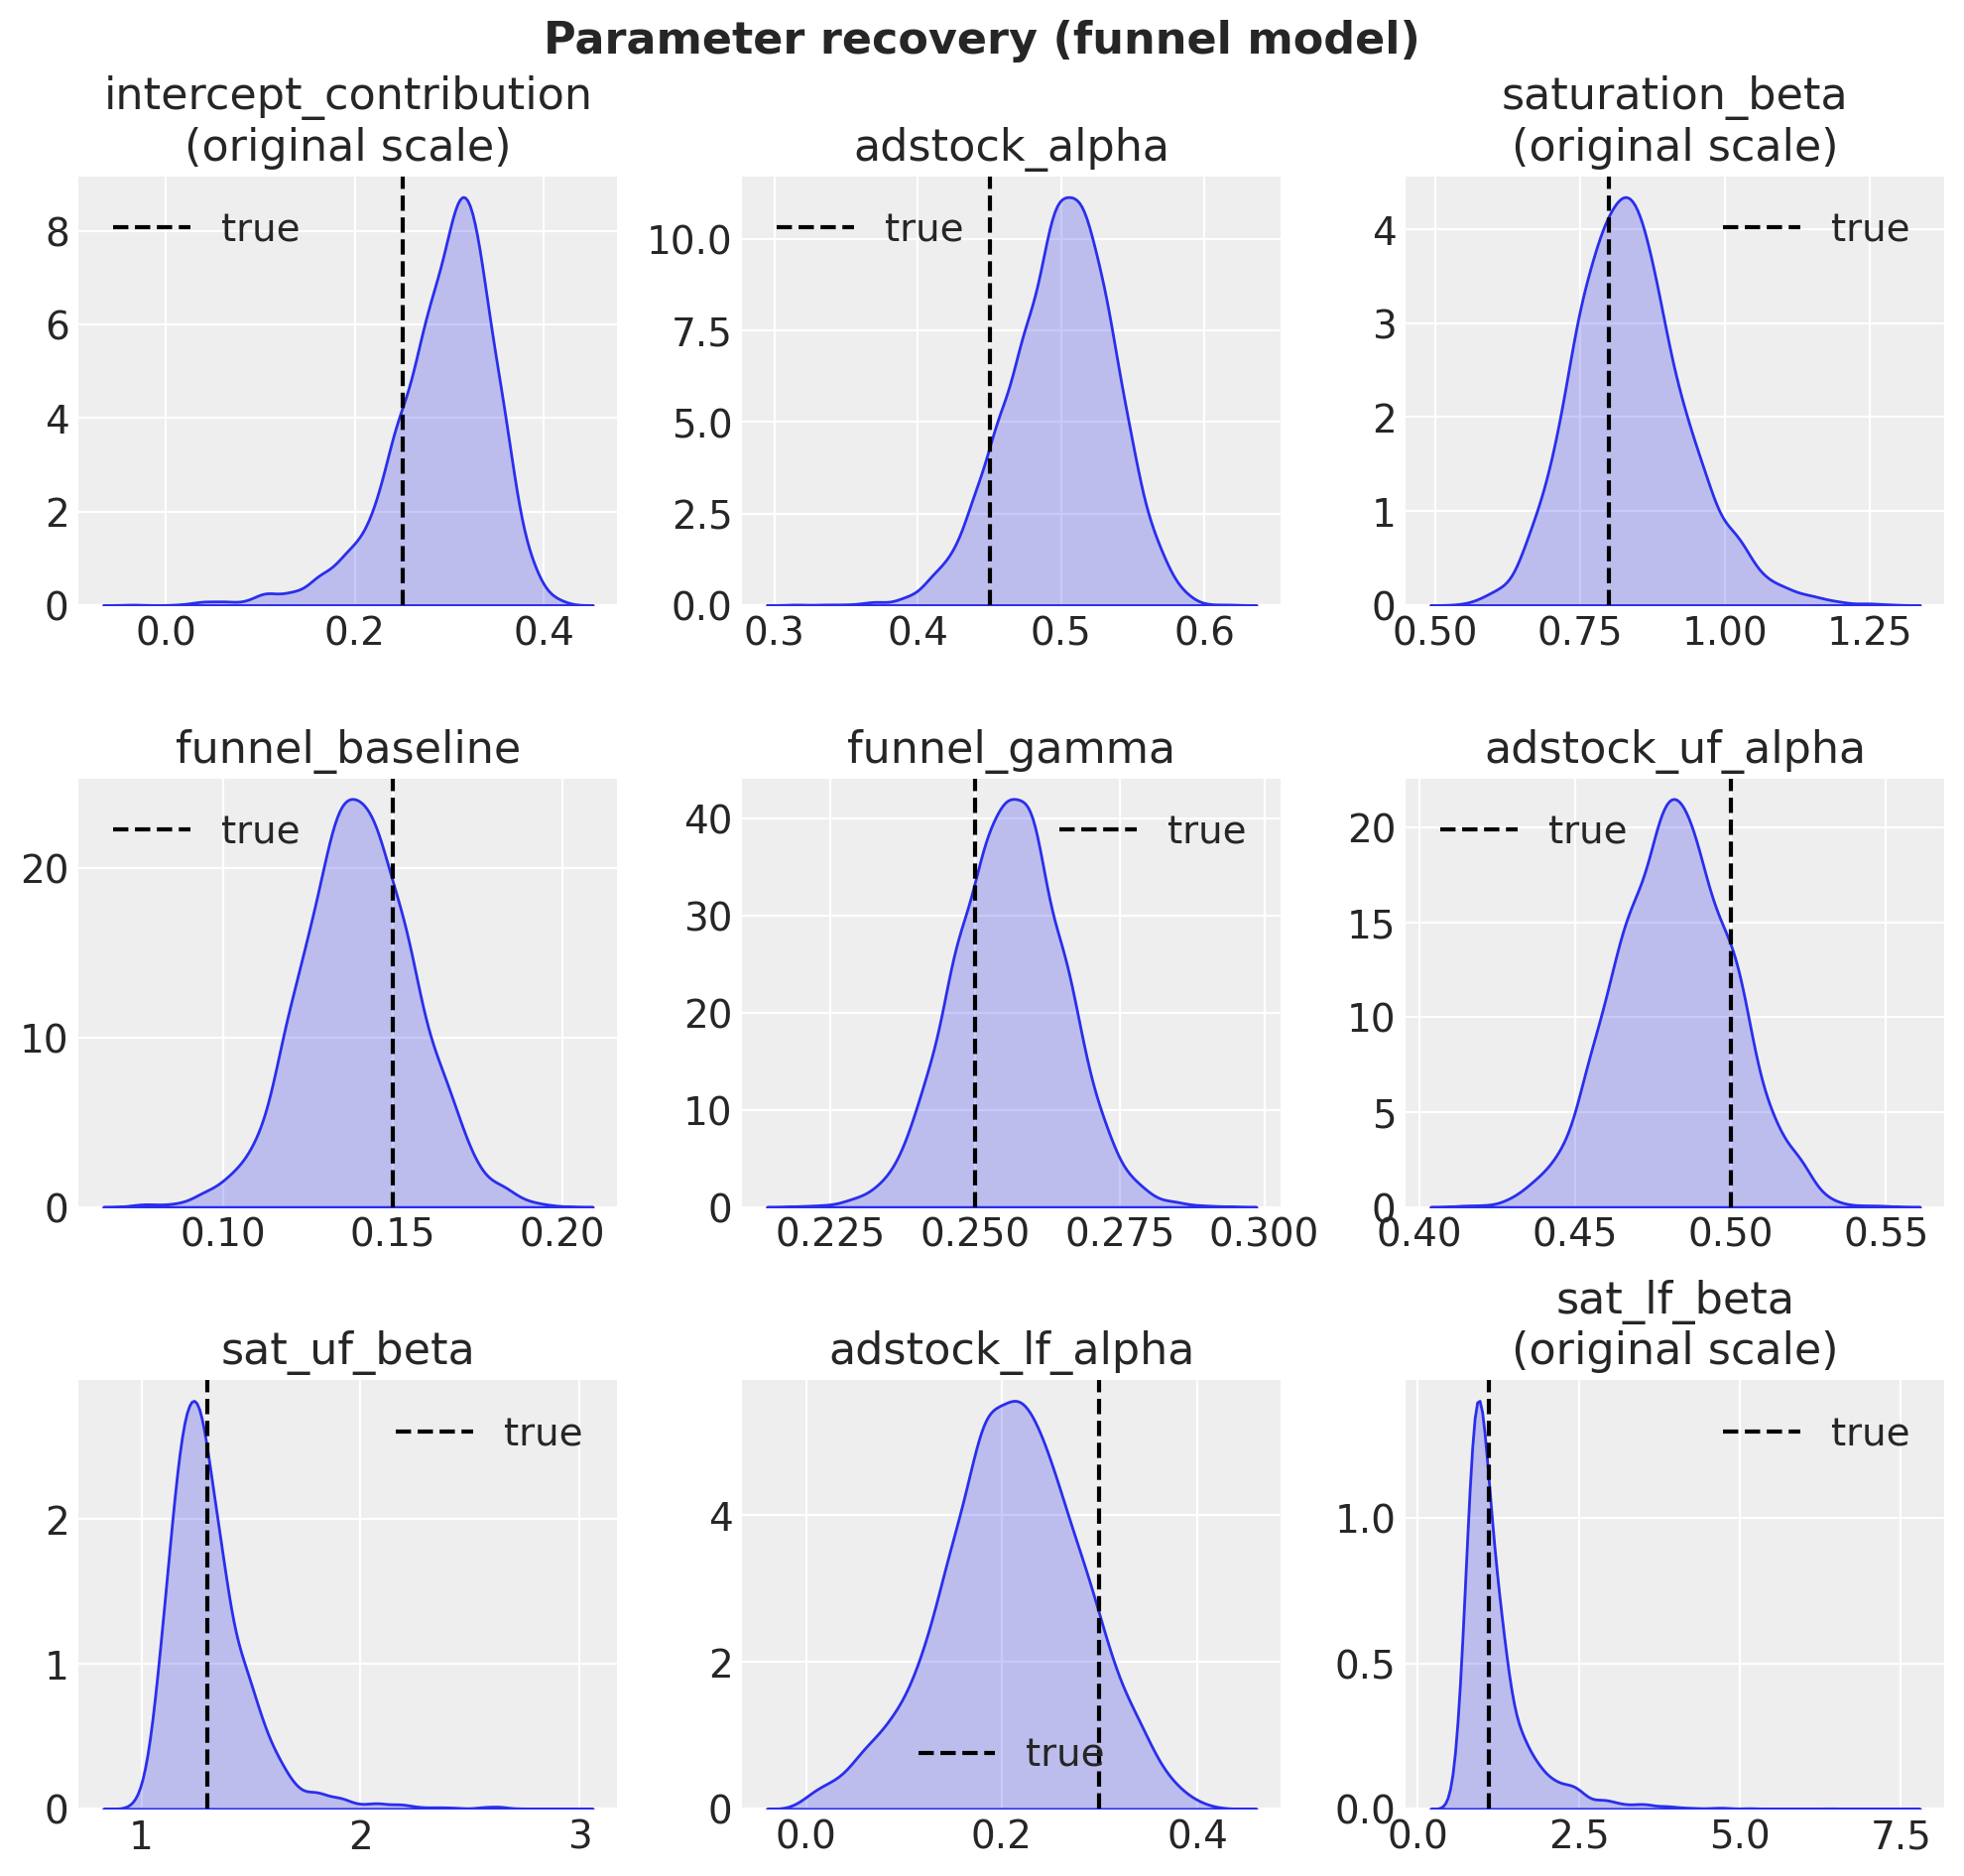

In [24]:
target_scale = float(funnel.idata.constant_data["target_scale"].squeeze())

# (title, variable, channel index, rescale to original target scale)
recovery = [
    ("intercept_contribution", "intercept_contribution", None, True),
    ("adstock_alpha", "adstock_alpha", 0, False),
    ("saturation_beta", "saturation_beta", 0, True),
    ("funnel_baseline", "funnel_baseline", None, False),
    ("funnel_gamma", "funnel_gamma", None, False),
    ("adstock_uf_alpha", "adstock_uf_alpha", None, False),
    ("sat_uf_beta", "sat_uf_beta", None, False),
    ("adstock_lf_alpha", "adstock_lf_alpha", None, False),
    ("sat_lf_beta", "sat_lf_beta", None, True),
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(FIG_WIDTH, FIG_HEIGHT * 1.6))
for ax, (title, var, idx, rescale) in zip(axes.flatten(), recovery, strict=True):
    draws = funnel.idata.posterior[var]
    if idx is not None:
        draws = draws.isel({"channel": idx})
    if rescale:
        draws = draws * target_scale
        title = f"{title}\n(original scale)"
    sns.kdeplot(draws.to_numpy().ravel(), ax=ax, color=COLOR_DIRECT, fill=True)
    ax.axvline(float(true[var]), color=COLOR_TRUE, linestyle="--", label="true")
    ax.set(title=title, ylabel="")
    ax.legend()
fig.suptitle("Parameter recovery (funnel model)", fontsize=16, fontweight="bold")
fig.tight_layout();

The parameters are recovered well. One scaling convention to keep in mind when reading the plot: the MMM standardizes its target internally (dividing by `max(y)`), so amplitude coefficients (`intercept_contribution`, `saturation_beta`, `sat_lf_beta`) are estimated on the scaled target, while the ground-truth values were defined on the unscaled one. The plot therefore multiplies those posteriors by `target_scale` before comparing. Parameters that act on the *inputs* (adstock decays) or on the *raw mediator* (`funnel_baseline`, `funnel_gamma`, `sat_uf_beta`, fit through the second likelihood on lower-funnel spend) are scale-free and are compared directly.

A separate, genuine effect remains: the **direct** upper $\to$ target saturation and the **lower-funnel** saturation are only weakly identified *individually*; both paths ultimately trace back to upper spend, so their split is not sharply pinned down and those two posteriors stay comparatively wide even after rescaling. As we will see next, the **total** upper-funnel effect is nonetheless recovered accurately.


## Direct, indirect, and total effect

We reconstruct the funnel model's estimate of each path in original scale. The direct path is the base channel contribution (which is already the counterfactual versus zero spend, since saturation of zero is zero). The indirect path is the mediated contribution **minus** what it would be with `upper_spend` set to zero.


In [25]:
X_zero = make_mmm_dataset(df.assign(upper_spend=0.0))

cf = funnel.sample_posterior_predictive(
    X_zero,
    extend_idata=False,
    combined=False,
    var_names=["funnel_effect_contribution_original_scale"],
    random_seed=rng,
)

direct_post = funnel.idata.posterior["channel_contribution_original_scale"].sel(
    channel="upper_spend"
)
indirect_post = (
    funnel.idata.posterior["funnel_effect_contribution_original_scale"]
    - cf["funnel_effect_contribution_original_scale"]
)
total_post = direct_post + indirect_post

Sampling: []


Output()

**Caption:** Funnel model recovery of direct, indirect, and total upper-funnel contributions (posterior mean and 94% HDI) vs. ground truth (black dashed), weekly original scale.


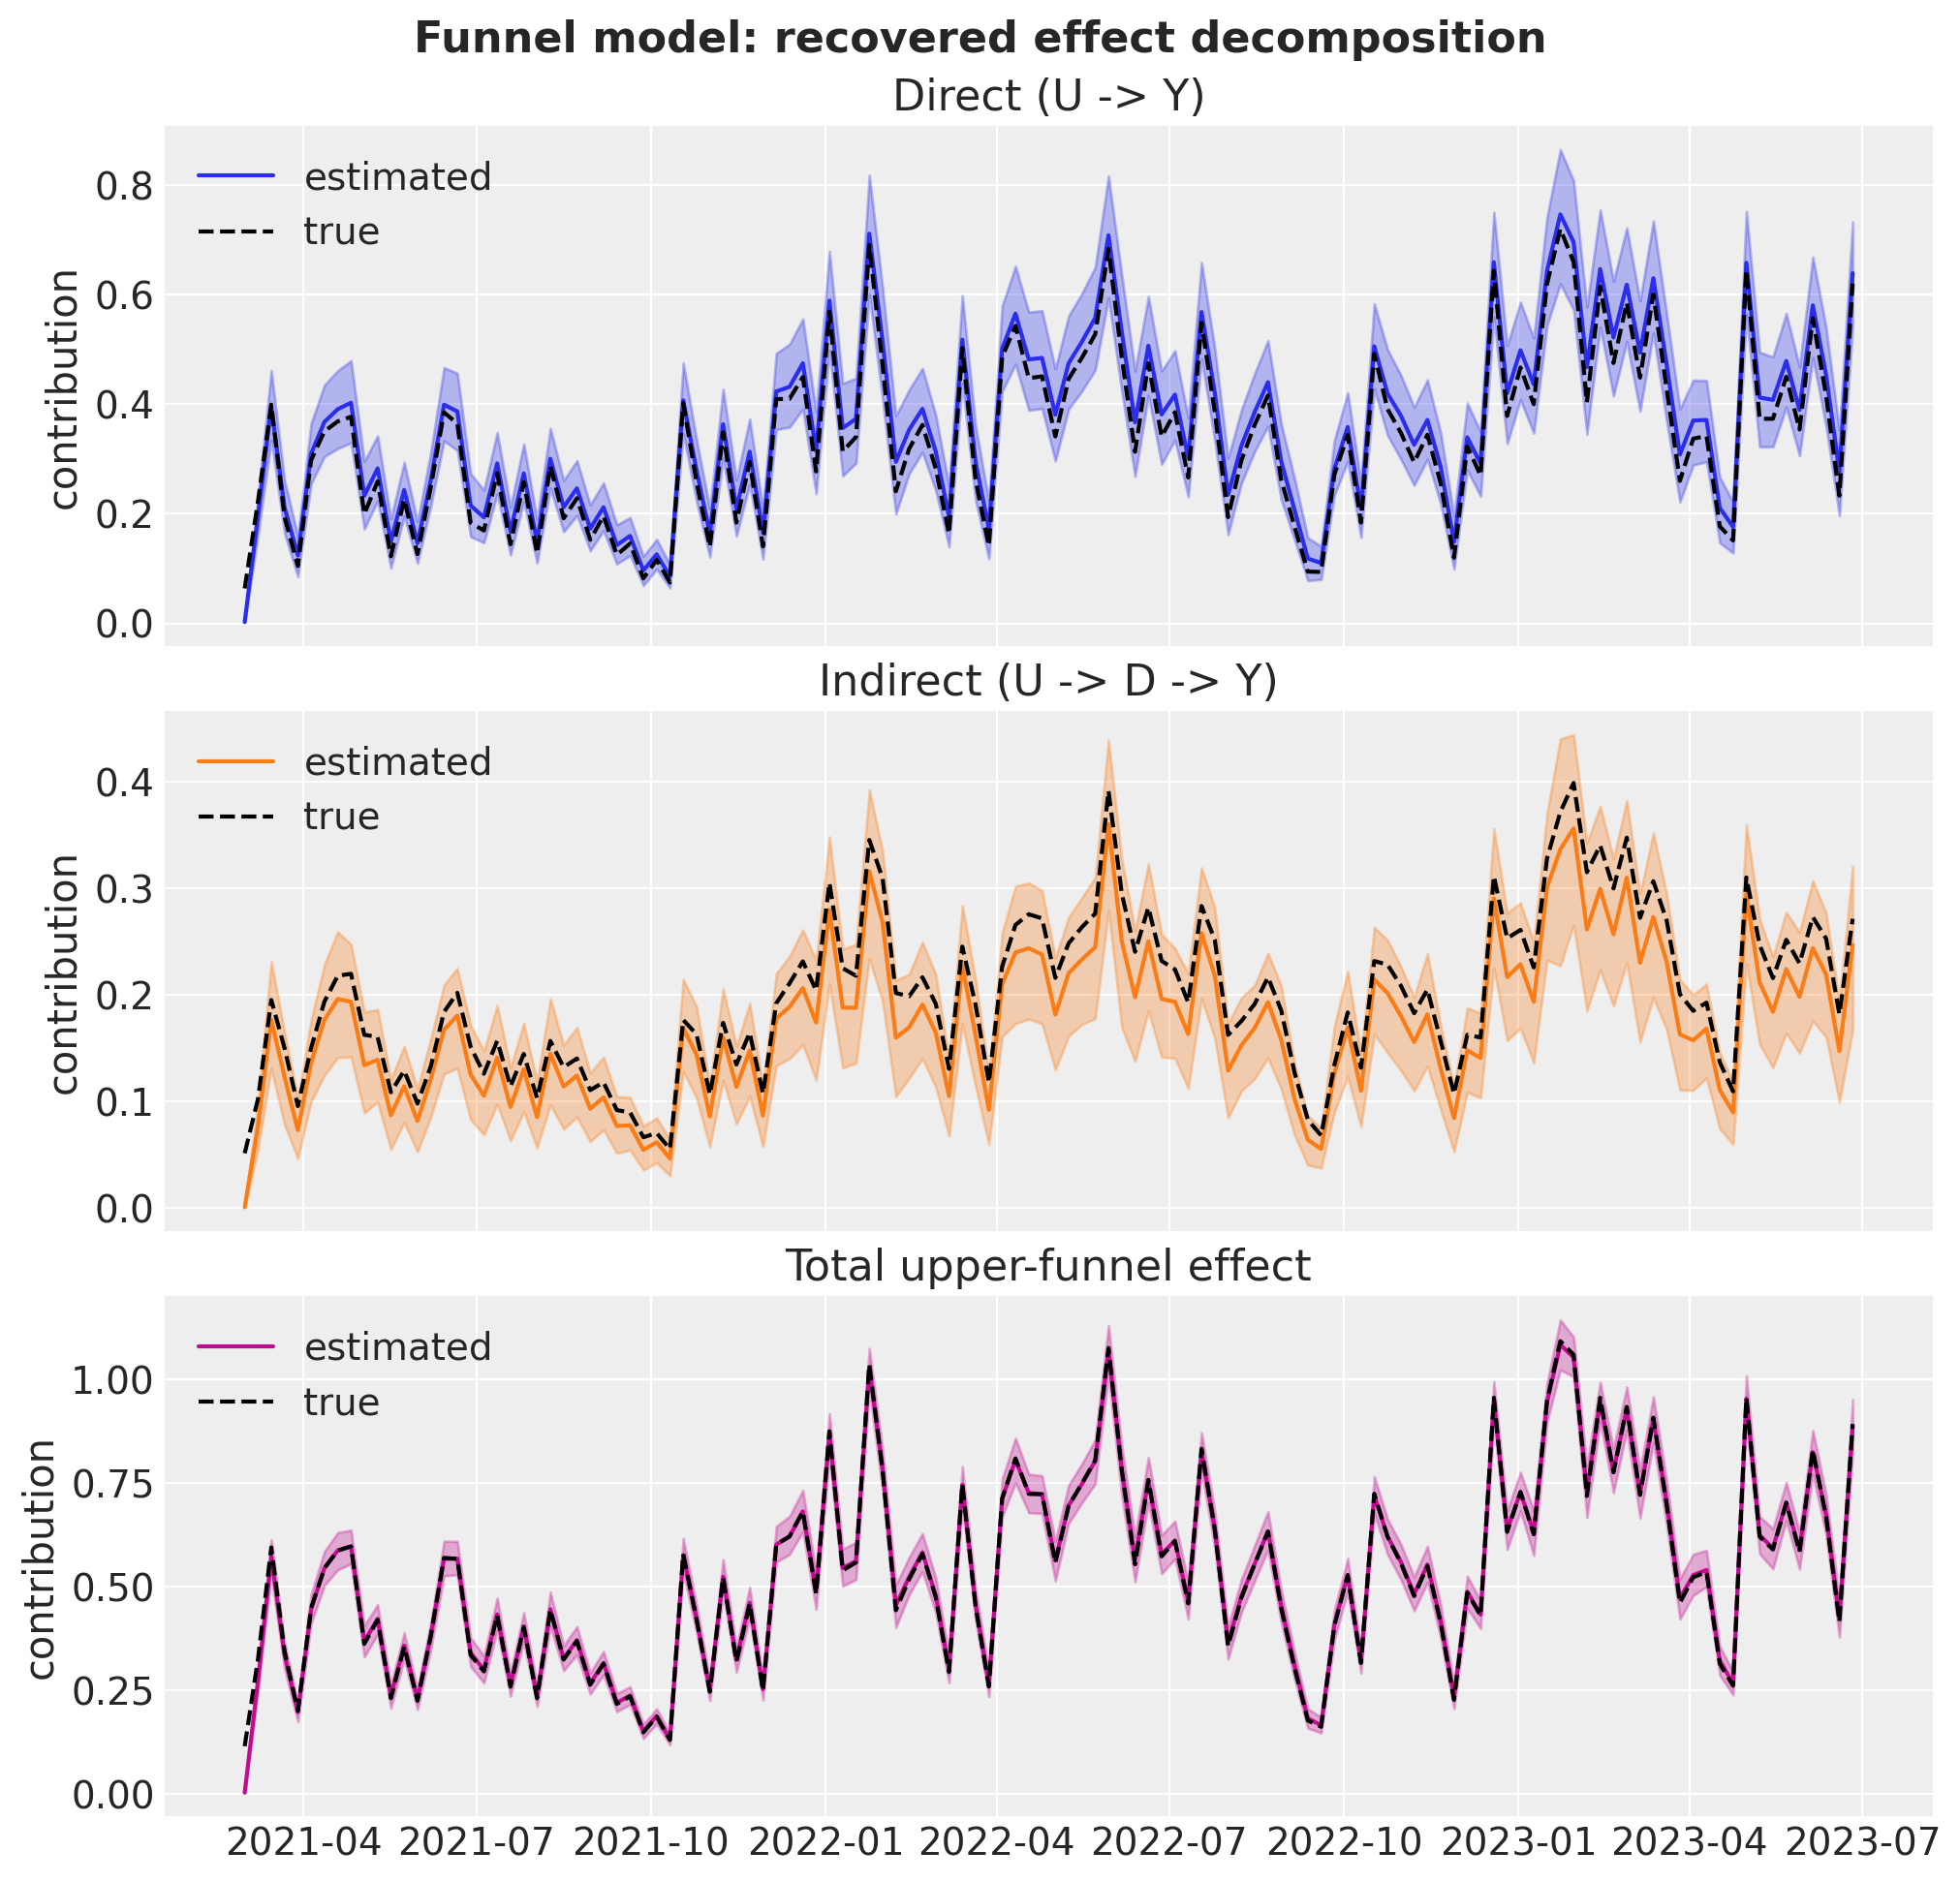

In [26]:
fig, axes = plt.subplots(nrows=3, figsize=(FIG_WIDTH, FIG_HEIGHT * 1.6), sharex=True)
for ax, post, truth, title, color in [
    (axes[0], direct_post, "direct_true", "Direct (U -> Y)", COLOR_DIRECT),
    (axes[1], indirect_post, "indirect_true", "Indirect (U -> D -> Y)", COLOR_INDIRECT),
    (axes[2], total_post, "total_upper_true", "Total upper-funnel effect", "C3"),
]:
    m = post.mean(dim=["chain", "draw"]).to_numpy()
    lo, hi = hdi_bounds(post)
    ax.fill_between(df["date"], lo, hi, alpha=0.3, color=color)
    ax.plot(df["date"], m, color=color, label="estimated")
    ax.plot(df["date"], df[truth], color=COLOR_TRUE, linestyle="--", label="true")
    ax.set(title=title, ylabel="contribution")
    ax.legend(loc="upper left")
fig.suptitle(
    "Funnel model: recovered effect decomposition", fontsize=16, fontweight="bold"
);

## Head-to-head: the bias from ignoring the funnel

Finally we compare the three models on the quantity a budget decision actually depends on: the **total contribution of upper-funnel spend**. For the naive models the upper channel contribution is already the counterfactual versus zero spend. For the funnel model we use the direct plus (counterfactual) indirect contribution computed above.


In [27]:
naive_a_upper = (
    naive_a.idata.posterior["channel_contribution_original_scale"]
    .sel(channel="upper_spend")
    .mean(dim="date")
)
naive_b_upper = (
    naive_b.idata.posterior["channel_contribution_original_scale"]
    .sel(channel="upper_spend")
    .mean(dim="date")
)
funnel_upper = total_post.mean(dim="date")

true_upper = float(df["total_upper_true"].mean())

estimates = {
    "Naive A\n(mediator as channel)": naive_a_upper,
    "Naive B\n(mediator omitted)": naive_b_upper,
    "Funnel": funnel_upper,
}

**Caption:** Posterior distribution of mean-over-time total upper-funnel contribution by model vs. ground-truth total (black dashed). Bias percentage in panel titles.


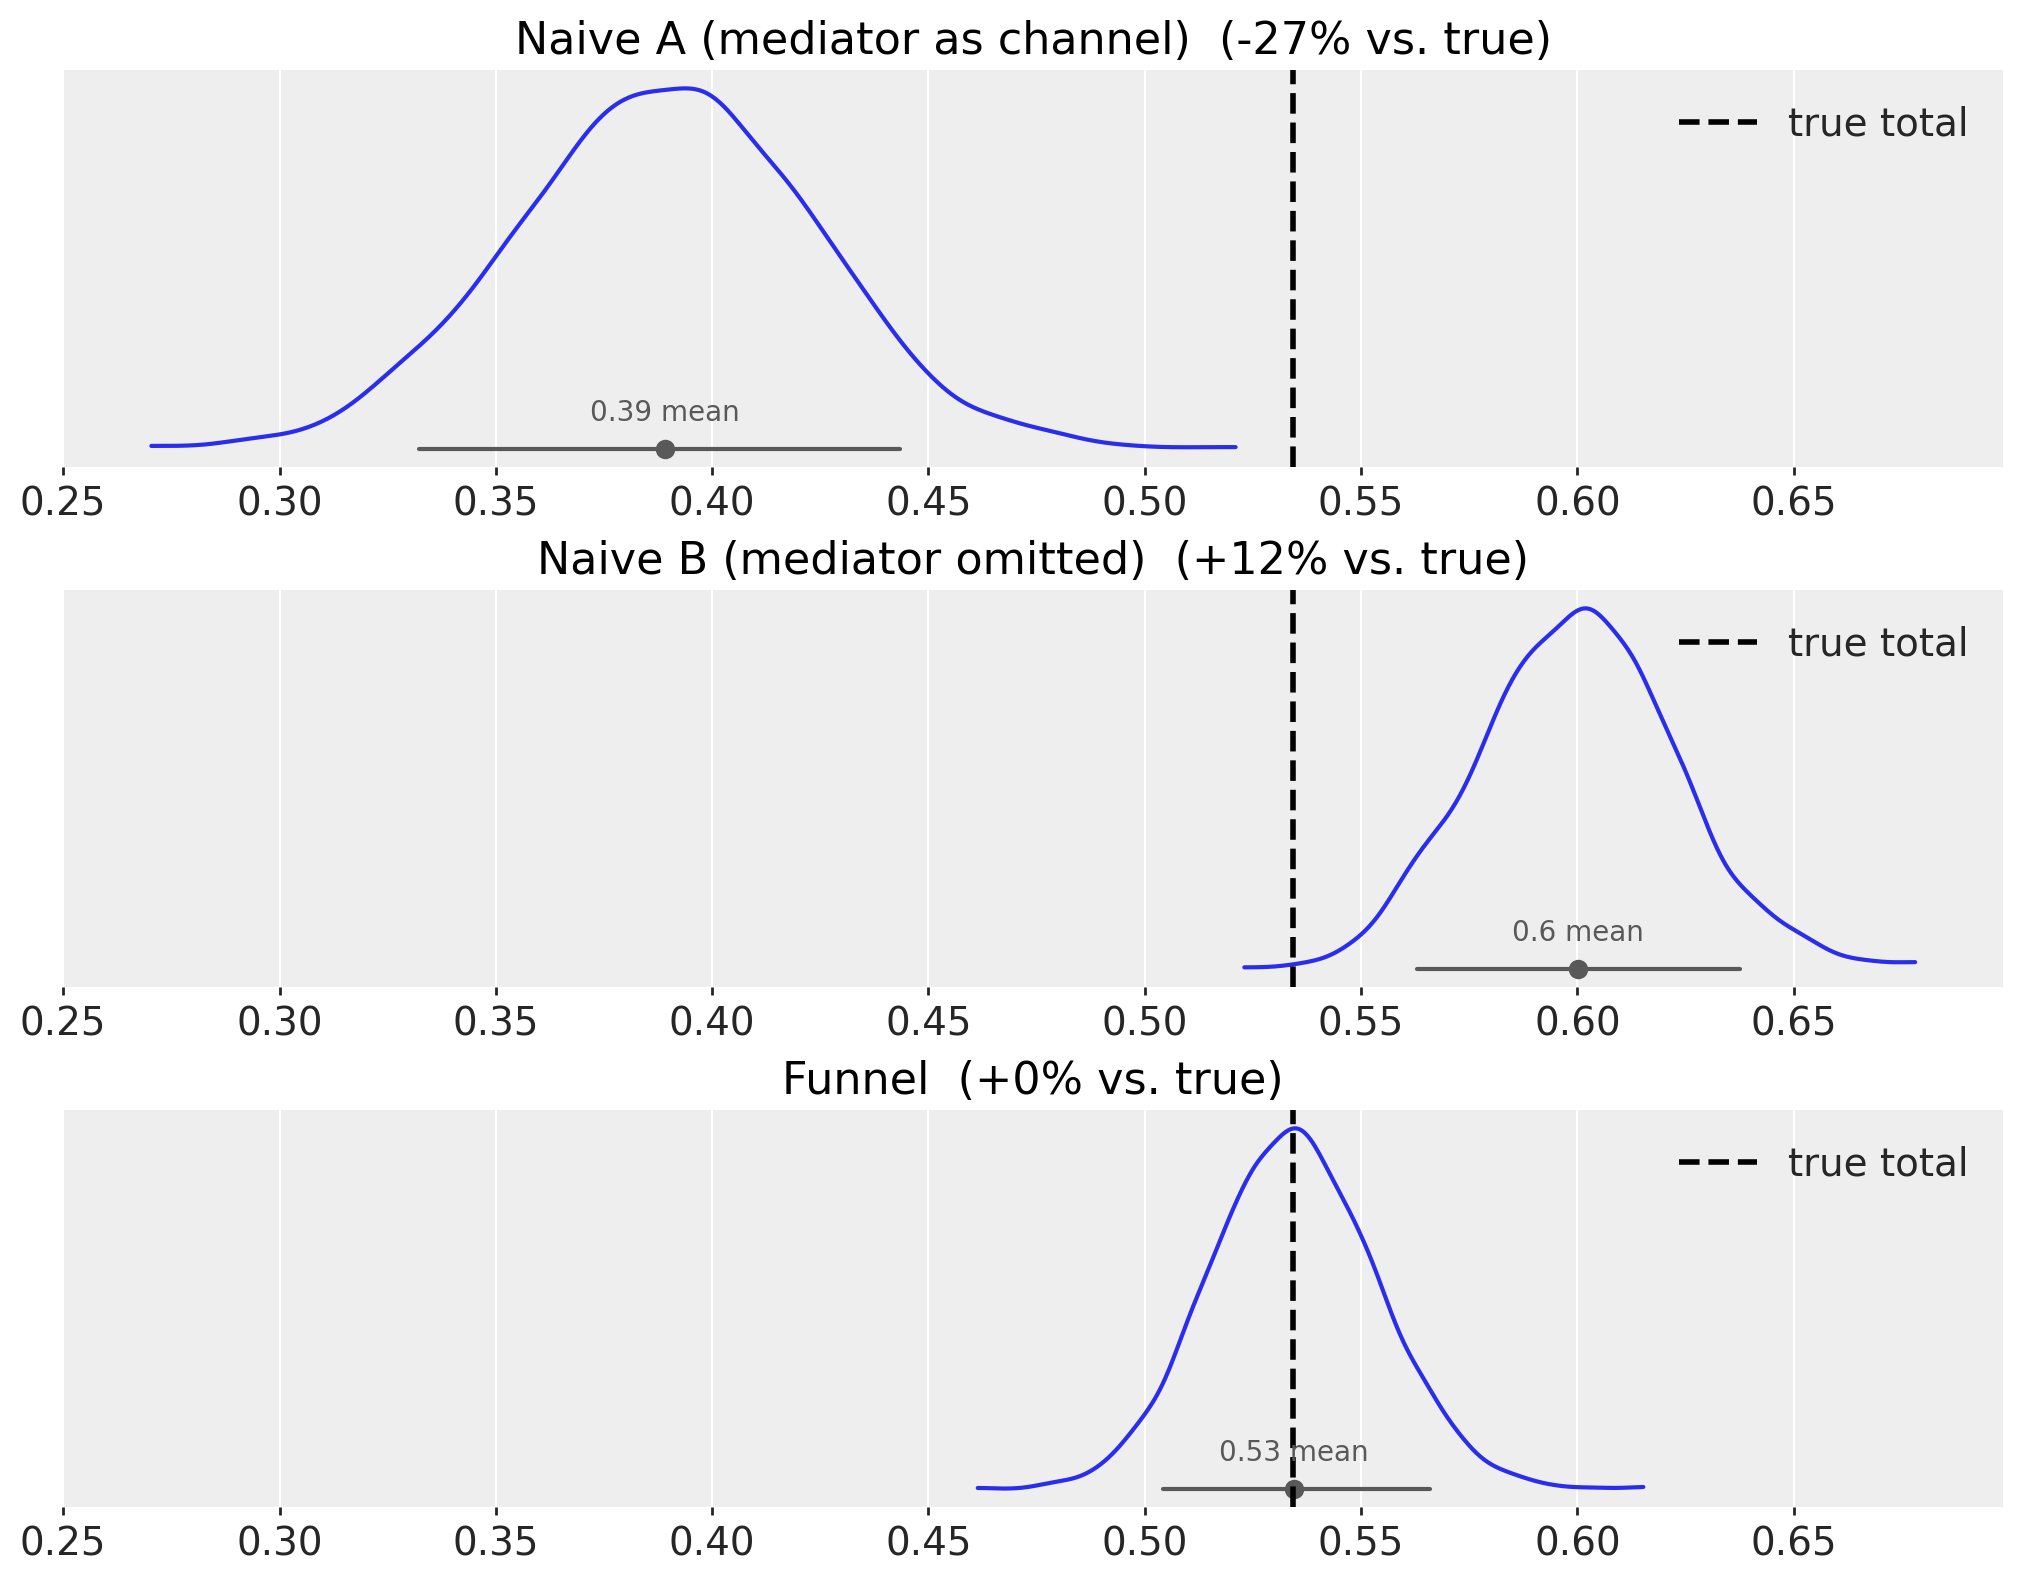

In [28]:
labels = list(estimates)
means = [float(v.mean()) for v in estimates.values()]


def _bare(da):
    """Drop chain/draw coordinate labels so arrays combine positionally."""
    return da.drop_vars([c for c in ("chain", "draw") if c in da.coords])


contrib_ds = xr.Dataset(
    {lab.replace("\n", " "): _bare(da) for lab, da in estimates.items()}
)

pc = azp.plot_dist(
    contrib_ds,
    col_wrap=1,
    figure_kwargs={
        "figsize": (FIG_WIDTH, FIG_HEIGHT * 1.3),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
for ax, name in zip(fig.axes, contrib_ds.data_vars, strict=True):
    ax.axvline(
        true_upper, color=COLOR_TRUE, linestyle="--", linewidth=2, label="true total"
    )
    bias = float(contrib_ds[name].mean()) / true_upper - 1
    ax.set_title(f"{name}  ({bias:+.0%} vs. true)")
    ax.legend(loc="upper right")

**Both naive models are biased.** Including the mediator as a channel (Naive A) blocks the indirect path and understates the upper-funnel effect; omitting it (Naive B) forces a single response curve to absorb the whole funnel (direct effect, mediated effect, and the control-driven lower-funnel demand that upper spend never caused), which here overstates it. That the two biases happen to point in opposite directions is incidental; the point is that neither naive specification recovers the truth. Only the funnel model does.

We can also express this as a return-on-ad-spend (ROAS) style ratio (total contribution per unit of upper-funnel spend), since that is the number a budget allocation keys off. We use the built-in `incrementality` module (`contribution_over_spend`), which runs an on/off counterfactual on spend and reads the resulting change in the linear predictor.

Because `FunnelEffect` opted in through `incrementality_spec`, that counterfactual is followed down **both** paths: the change in `channel_contribution` and the change in `funnel_effect_contribution` are added together, so the module returns the **total** upper-funnel ROAS rather than the direct part of it. Had the effect not opted in, the module would raise instead of quietly reporting the direct path as if it were the whole thing. The naive models have no mediator subgraph, so their ROAS is simply what each model attributes to `upper_spend`.

The check below is the point of the whole notebook in one number: the module's mediated ROAS should land on the direct-plus-indirect ROAS we assembled by hand with an explicit posterior-predictive counterfactual, and both should sit near the truth. They are not identical, and should not be: the incrementality module intervenes on **spend** and attributes each period's response within a carryover window, while the hand-rolled version compares two full-series predictions.


In [29]:
total_upper_spend = df["upper_spend"].sum()


def upper_roas(model):
    """All-time ROAS of upper_spend via the incrementality module."""
    roas = model.incrementality.contribution_over_spend(frequency="all_time")
    return roas.sel(channel="upper_spend")


roas_naive_a = upper_roas(naive_a)
roas_naive_b = upper_roas(naive_b)
# Funnel via incrementality: direct + mediated, since the effect opted in.
roas_funnel = upper_roas(funnel)
# The same quantity assembled by hand above, as a cross-check.
roas_funnel_manual = total_post.sum(dim="date") / total_upper_spend

true_roas = float(df["total_upper_true"].sum() / total_upper_spend)
true_direct_roas = float(df["direct_true"].sum() / total_upper_spend)

**Caption:** Posterior distributions of upper-funnel ROAS by model (contribution per unit of `upper_spend`, all-time). Black dashed: true total ROAS; gray dotted: true direct ROAS only.


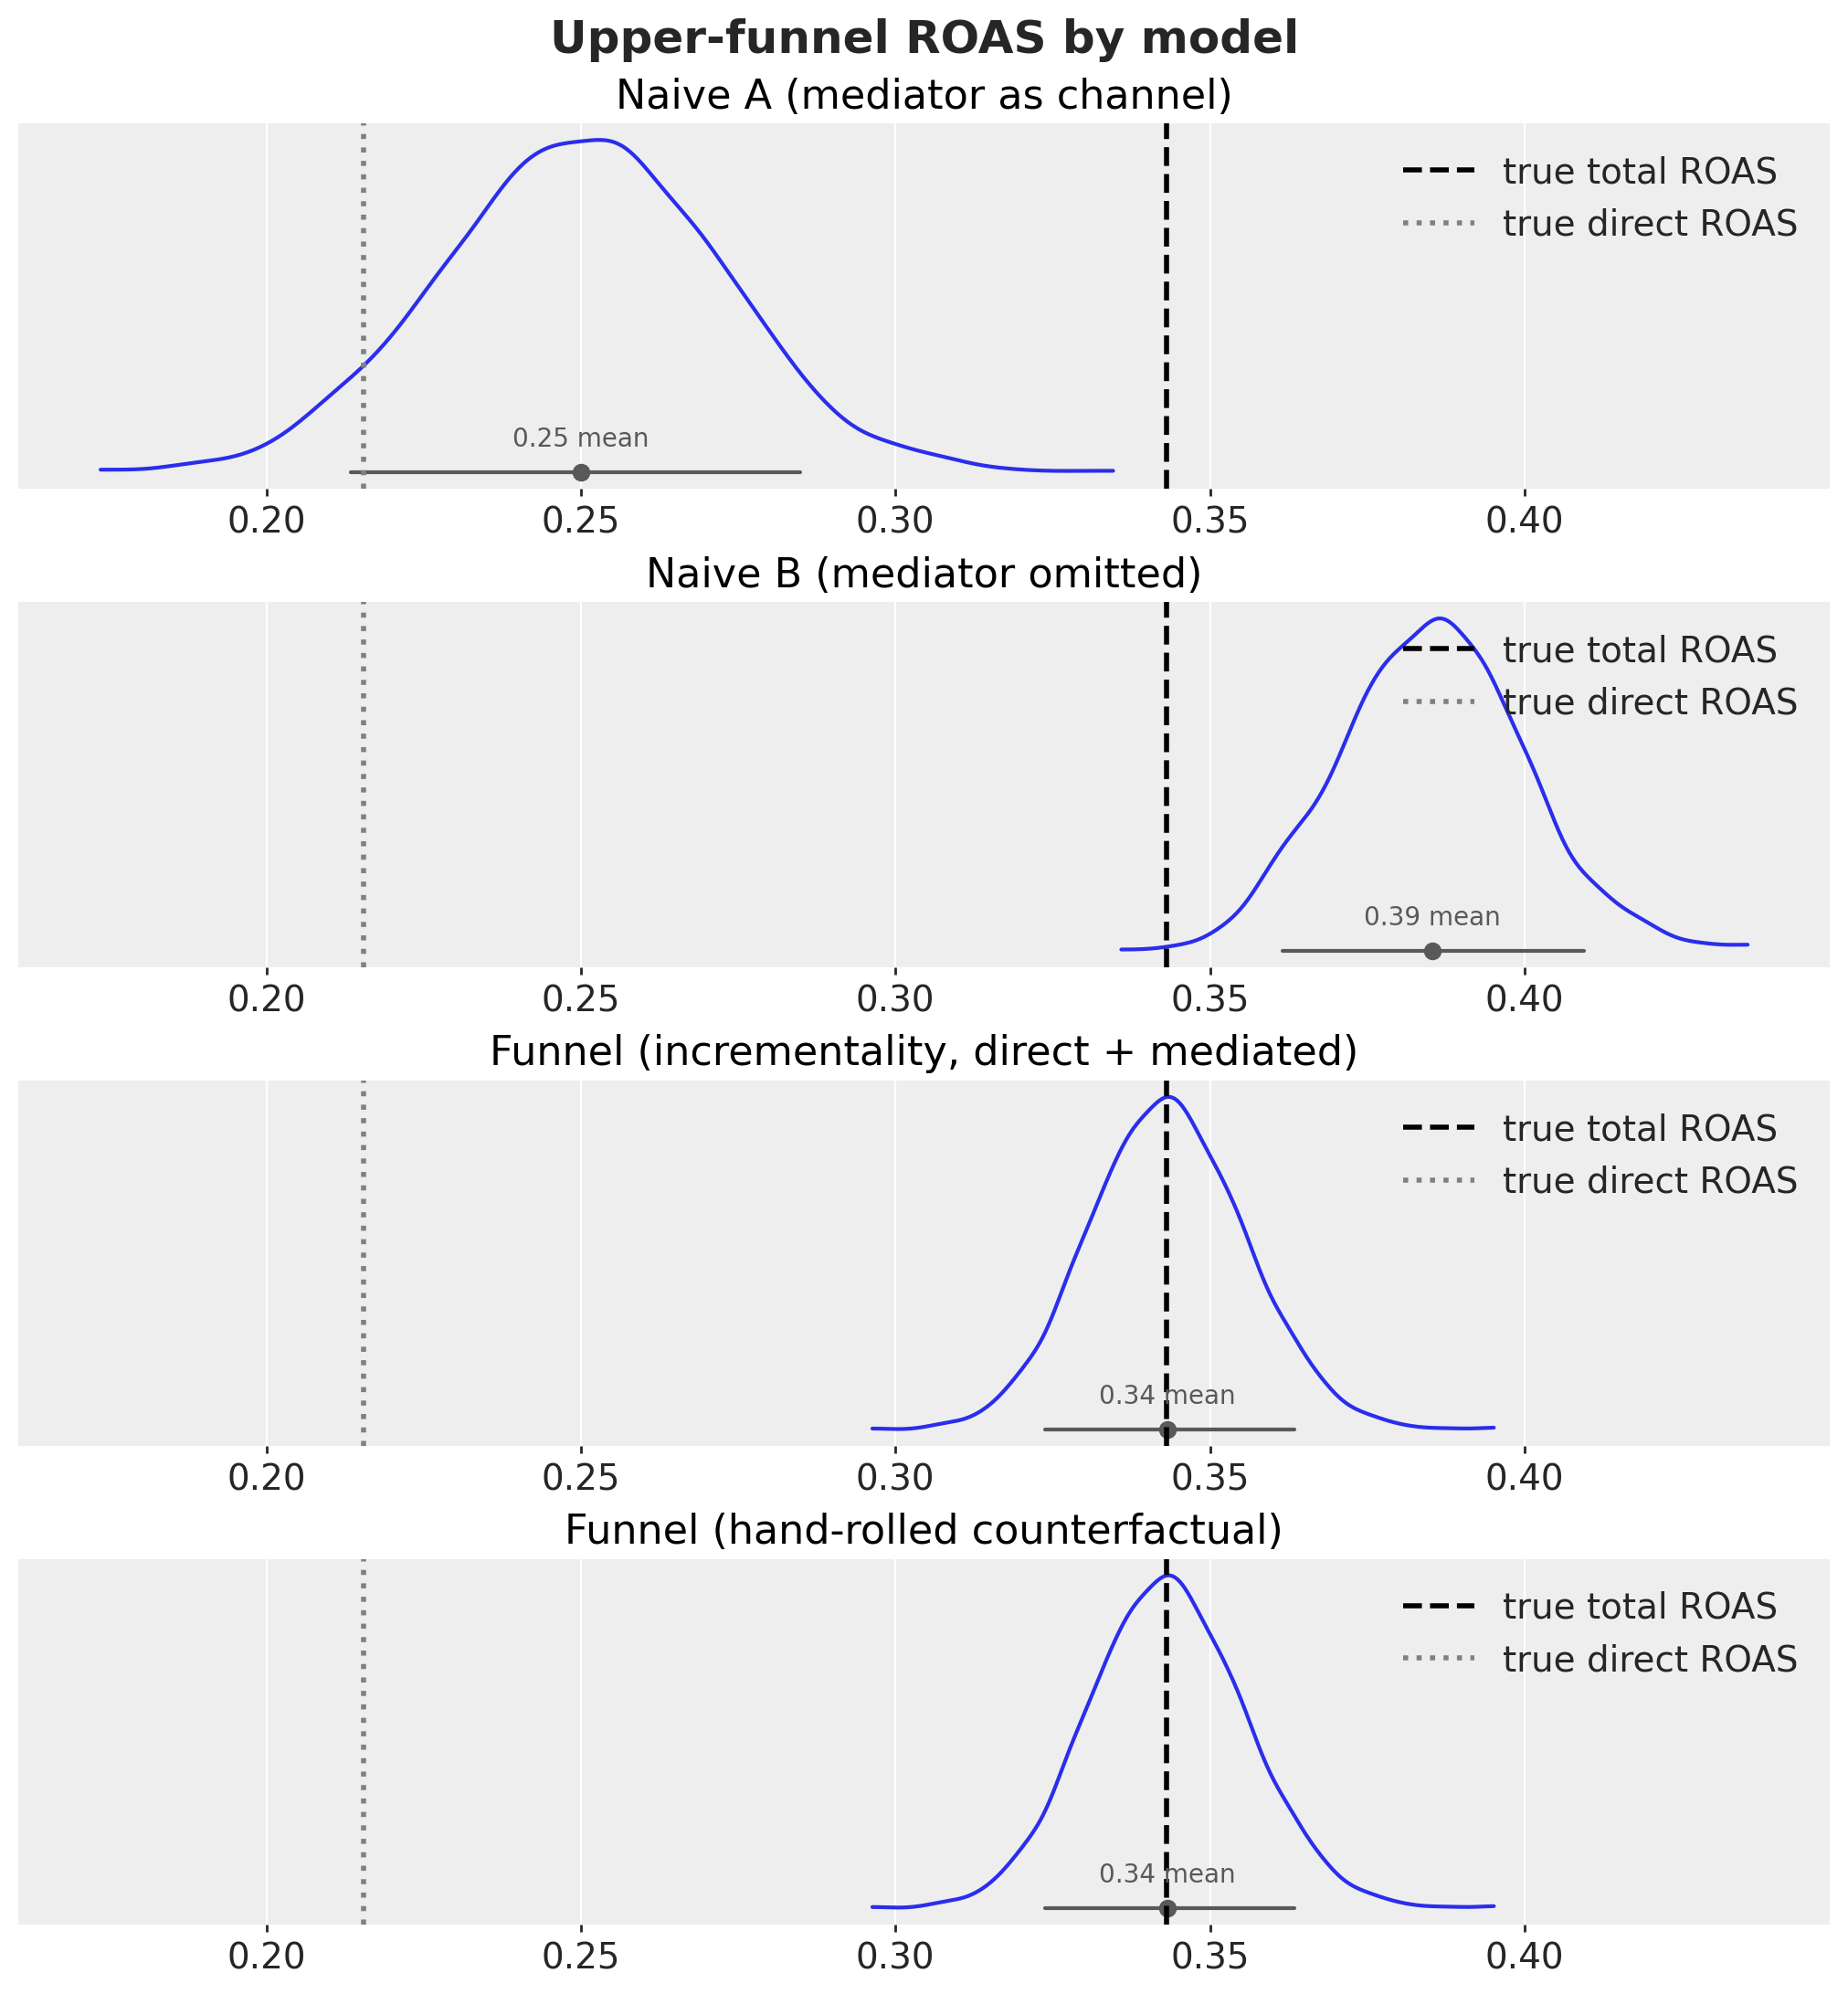

In [30]:
roas_ds = xr.Dataset(
    {
        "Naive A (mediator as channel)": _bare(roas_naive_a),
        "Naive B (mediator omitted)": _bare(roas_naive_b),
        "Funnel (incrementality, direct + mediated)": _bare(roas_funnel),
        "Funnel (hand-rolled counterfactual)": _bare(roas_funnel_manual),
    }
)

pc = azp.plot_dist(
    roas_ds,
    col_wrap=1,
    figure_kwargs={
        "figsize": (FIG_WIDTH, FIG_HEIGHT * 1.8),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
for ax, name in zip(fig.axes, roas_ds.data_vars, strict=True):
    ax.axvline(
        true_roas,
        color=COLOR_TRUE,
        linestyle="--",
        linewidth=2,
        label="true total ROAS",
    )
    ax.axvline(
        true_direct_roas,
        color="gray",
        linestyle=":",
        linewidth=2,
        label="true direct ROAS",
    )
    ax.set_title(name)
    ax.legend(loc="upper right")
fig.suptitle("Upper-funnel ROAS by model", fontsize=18, fontweight="bold");

In [31]:
roas_by_label = {
    "Naive A (mediator as channel)": float(roas_naive_a.mean()),
    "Naive B (mediator omitted)": float(roas_naive_b.mean()),
    "Funnel": float(roas_funnel.mean()),
}

summary = pd.DataFrame(
    {
        "mean_contribution": means,
        "bias_vs_true": [(m - true_upper) / true_upper for m in means],
        "roas": [roas_by_label[lab.replace("\n", " ")] for lab in labels],
    },
    index=[lab.replace("\n", " ") for lab in labels],
)
summary.loc["True"] = [true_upper, 0.0, true_roas]
summary.style.format(
    {"mean_contribution": "{:.3f}", "bias_vs_true": "{:+.1%}", "roas": "{:.3f}"}
)

,mean_contribution,bias_vs_true,roas
Naive A (mediator as channel),0.389,-27.2%,0.250
Naive B (mediator omitted),0.600,+12.3%,0.385
Funnel,0.534,+0.0%,0.343
True,0.534,+0.0%,0.343


### Predictive fit vs. causal bias

In-sample $R^2$ tells a **split story**. **Naive A** (mediator as channel) can match the funnel model's $R^2$ while carrying the largest causal bias; fit alone does not flag that misspecification. **Naive B** (mediator omitted) is also biased but shows materially worse in-sample fit (~80% more residual variance in the issue review), so fit partially signals that error. We therefore do **not** claim that "held-out error alone cannot catch funnel misspecification" without distinguishing the two naive models.

Below we report in-sample metrics on the full series, then refit each model on the first 80% of weeks and score the held-out last 20% (simple time split; assuming no structural break).


**Caption:** In-sample RMSE, $R^2$, and CRPS on the full weekly series (original target scale; CRPS scores the full posterior predictive, lower is better).


In [32]:
metrics_rows = []
for label, m in [("Naive A", naive_a), ("Naive B", naive_b), ("Funnel", funnel)]:
    rmse, r2, crps_val = compute_target_metrics(m, df["y_obs"].to_numpy())
    metrics_rows.append(
        {"model": label, "split": "in_sample", "RMSE": rmse, "R2": r2, "CRPS": crps_val}
    )

pd.DataFrame(metrics_rows).set_index(["model", "split"]).style.format(
    {"RMSE": "{:.4f}", "R2": "{:.4f}", "CRPS": "{:.4f}"}
)

,,RMSE,R2,CRPS
model,split,,,
Naive A,in_sample,0.0485,0.9649,0.0277
Naive B,in_sample,0.0627,0.9412,0.0355
Funnel,in_sample,0.0467,0.9675,0.0266


### Holdout evaluation

We hold out the last 20% of weeks, refit each model on the training window, and score posterior-predictive $Y$ on the test dates. This assumes no structural break between train and test.


In [33]:
holdout_frac = 0.2
n_test = max(1, int(np.ceil(holdout_frac * len(df))))
train_df = df.iloc[:-n_test].copy()
test_df = df.iloc[-n_test:].copy()
test_dates = pd.to_datetime(test_df["date"])

X_train = train_df[["date", "upper_spend", "lower_spend"]]
X_test = test_df[["date", "upper_spend", "lower_spend"]]
X_funnel_train = make_mmm_dataset(train_df)
X_funnel_test = make_mmm_dataset(test_df)
y_train = train_df["y_obs"]
y_test = test_df["y_obs"].to_numpy()


def fit_holdout_naive_a():
    m = MMM(
        date_column="date",
        target_column="y_obs",
        channel_columns=["upper_spend", "lower_spend"],
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        sampler_config=sampler_config,
    )
    m.build_model(X_train, y_train)
    m.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
    m.fit(X_train, y_train, **sample_kwargs)
    m.sample_posterior_predictive(X_test, random_seed=rng)
    return m


def fit_holdout_naive_b():
    m = MMM(
        date_column="date",
        target_column="y_obs",
        channel_columns=["upper_spend"],
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        sampler_config=sampler_config,
    )
    m.build_model(X_train[["date", "upper_spend"]], y_train)
    m.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
    m.fit(X_train[["date", "upper_spend"]], y_train, **sample_kwargs)
    m.sample_posterior_predictive(X_test[["date", "upper_spend"]], random_seed=rng)
    return m


def fit_holdout_funnel():
    m = MMM(
        date_column="date",
        target_column="y_obs",
        channel_columns=["upper_spend"],
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        sampler_config=sampler_config,
    )
    m.add_mu_effect(make_funnel_effect())
    m.build_model(X_funnel_train, y_train)
    m.add_original_scale_contribution_variable(
        var=["channel_contribution", "funnel_effect_contribution", "y"]
    )
    m.fit(X_funnel_train, y_train, **sample_kwargs)
    m.sample_posterior_predictive(X_funnel_test, random_seed=rng)
    return m


holdout_naive_a = fit_holdout_naive_a()
holdout_naive_b = fit_holdout_naive_b()
holdout_funnel = fit_holdout_funnel()

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

...

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma]


Output()

Output()

/Users/benjamv/git/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_likelihood, y]


Output()

**Caption:** Holdout RMSE, $R^2$, and CRPS on the last 20% of weeks after refitting on the training window (original target scale).


In [34]:
holdout_rows = []
for label, m in [
    ("Naive A", holdout_naive_a),
    ("Naive B", holdout_naive_b),
    ("Funnel", holdout_funnel),
]:
    rmse, r2, crps_val = compute_target_metrics(m, y_test, dates=test_dates)
    holdout_rows.append(
        {"model": label, "split": "holdout", "RMSE": rmse, "R2": r2, "CRPS": crps_val}
    )

all_metrics = pd.concat(
    [
        pd.DataFrame(metrics_rows),
        pd.DataFrame(holdout_rows),
    ],
    ignore_index=True,
)
all_metrics.set_index(["model", "split"]).style.format(
    {"RMSE": "{:.4f}", "R2": "{:.4f}", "CRPS": "{:.4f}"}
)

,,RMSE,R2,CRPS
model,split,,,
Naive A,in_sample,0.0485,0.9649,0.0277
Naive B,in_sample,0.0627,0.9412,0.0355
Funnel,in_sample,0.0467,0.9675,0.0266
Naive A,holdout,0.0963,0.8315,0.0462
Naive B,holdout,0.1248,0.7171,0.0593
Funnel,holdout,0.1027,0.8084,0.0491


**Naive A** remains close to the funnel model on holdout $R^2$ while its causal estimates are badly biased. The dangerous misspecification survives out of sample. **Naive B** is worse on both causal recovery and predictive fit. Neither pattern replaces asking the causal question directly; they show that fit is an incomplete diagnostic for funnel structure.


### Library decomposition check

Quick sanity check: the counterfactual decomposition API sees the funnel effect; the conserving `get_contributions()` path used by waterfall plots does not.


In [35]:
cf_vars = set(funnel.compute_counterfactual_contributions_dataset().data_vars)
contrib_vars = set(funnel.data.get_contributions(original_scale=True).data_vars)

print("In counterfactual decomposition:", "funnel_effect" in cf_vars)
print("In get_contributions buckets:", "funnel_effect" in contrib_vars)
print("get_contributions buckets:", sorted(contrib_vars))

In counterfactual decomposition: True
In get_contributions buckets: False
get_contributions buckets: ['baseline', 'channels']


## Caveats and extensions

This example keeps the funnel deliberately small. A few things to keep in mind before taking the pattern further:

**Causal structure and estimands**

- **The framework does not "see" the DAG.** The funnel structure lives entirely in the `FunnelEffect` code. To the `MMM` object, `funnel_effect_contribution` is just one more additive term. Incrementality is the exception: opting in through `incrementality_spec` is enough for a spend counterfactual to be propagated through the mediator, because the module perturbs spend and re-evaluates the graph rather than reading a stored decomposition. Splitting the result back into a *direct* and an *indirect* share is still yours to do, as we did above.
- **No lower-funnel budget lever in this DAG.** As noted above, `lower_spend` is a measurement of latent demand, not a cause of the target. Even a perfect optimizer would find nothing to allocate to lower funnel here; the limitation is the estimand, not only tooling.
- **Self-consistency, not robustness.** Recovery here holds because the fitted model matches the generative model. If observed lower spend genuinely drives the target, or if $U$ and $C$ are correlated, this specification can be wrong while still fitting well.

**Library integration** — follow-up work is tracked in [#2830](https://github.com/pymc-labs/pymc-marketing/issues/2830), [#2871](https://github.com/pymc-labs/pymc-marketing/issues/2871), [#2468](https://github.com/pymc-labs/pymc-marketing/issues/2468), and [#2804](https://github.com/pymc-labs/pymc-marketing/pull/2804).

**Implementation notes**

- **Budget optimization.** `BudgetOptimizer` does not substitute decision variables into `MuEffect` subgraphs out of the box; funnel-aware allocation is tracked in [#2804](https://github.com/pymc-labs/pymc-marketing/pull/2804).
- **Out-of-sample prediction.** Future `lower_control` values must be supplied (exogenous); future `lower_spend` values are placeholders; the second likelihood is resampled, so the model *forecasts* lower-funnel spend from the upper-funnel plan.
- **Ordering matters.** An effect that reads another effect's output must be appended after it, since `create_effect` runs in list order.

Natural extensions include **censored** lower-funnel spend, **multiple mediators**, and **time-varying** mediator baselines.

For a substantially more advanced treatment (several upper-funnel channels, a geo panel, a mediator that is itself media plus a demand *indicator*, and formal d-separation of every naive alternative), continue with {ref}`mmm_funnel_mueffect_advanced`.

**Reflection.** In your own domain, which variables are treatments, mediators, measurements, and excluded controls? Would conditioning on a lower-funnel channel block the very path you are trying to measure?


In [36]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Mon, 17 Aug 2026

Python implementation: CPython
Python version       : 3.12.9
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0
pytensor      : 3.0.7
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

